<a href="https://colab.research.google.com/github/gautamkr1876/AIML_ClassNotes/blob/main/7.%20Advanced%20AI%20Agents/9.Model%20Quantization%20Techniques/Model_Quantization_Techniques.ipynb" target="_blank">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# A Visual Guide to Quantization

### Demystifying the Compression of Large Language Models

---

As their name suggests, Large Language Models (LLMs) are often too large to run on consumer hardware. These models may exceed billions of parameters and generally need GPUs with large amounts of VRAM to speed up inference.

More and more research has been focused on making these models smaller through improved training, adapters, and other techniques. One major technique in this field is called **quantization**.

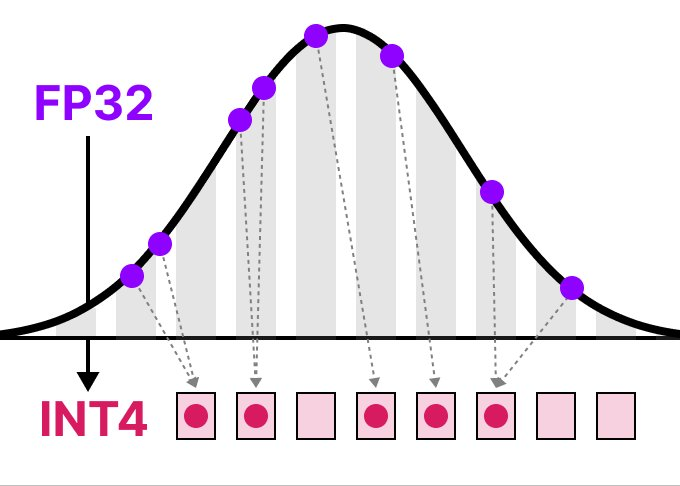


---
## The "Problem" with LLMs

LLMs get their name due to the number of parameters they contain. Nowadays, these models typically have billions of parameters (mostly *weights*) which can be quite expensive to store.

During inference, activations are created as a product of the input and the weights, which similarly can be quite large.

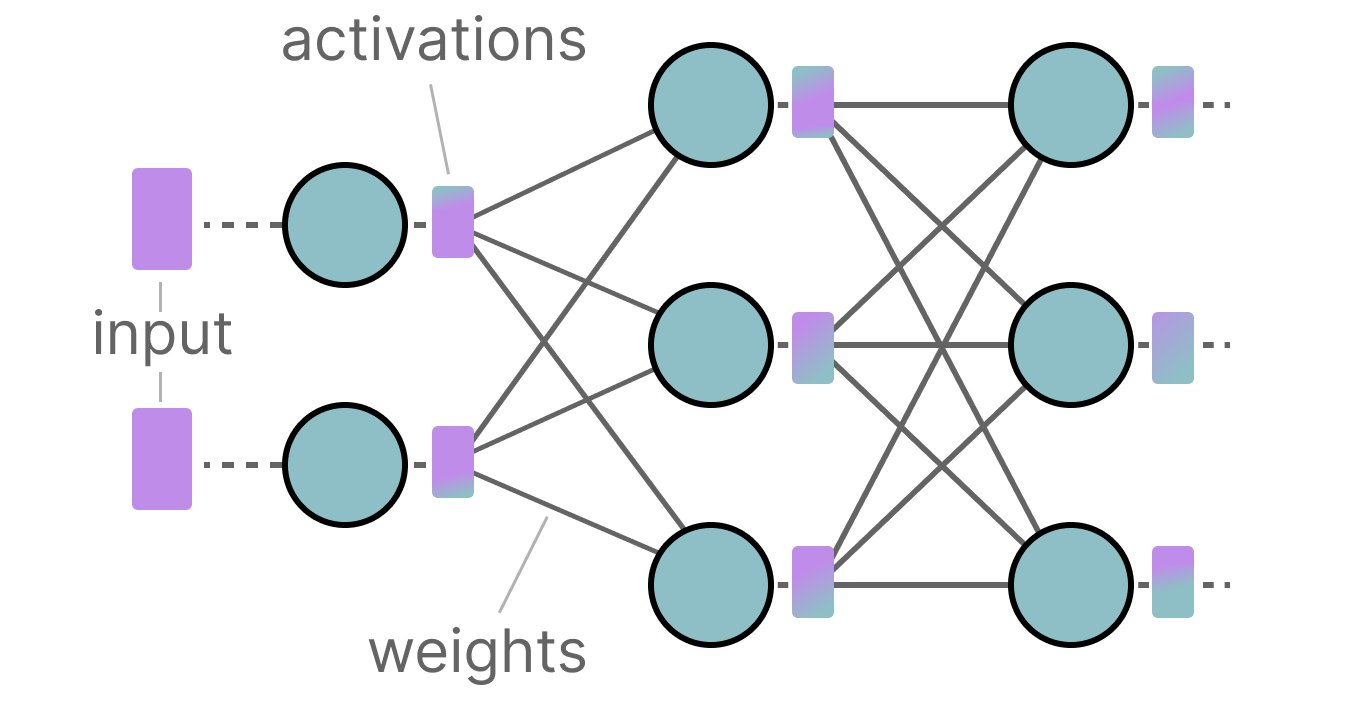

As a result, we would like to represent billions of values as efficiently as possible, minimizing the amount of space needed to store each value.


### How to Represent Numerical Values

A given value is often represented as a floating-point number (or *float*): a positive or negative number with a decimal point.

These values are represented by "bits" (binary digits). The IEEE-754 standard describes how bits can serve one of three roles: the **sign**, **exponent**, or **fraction** (mantissa).

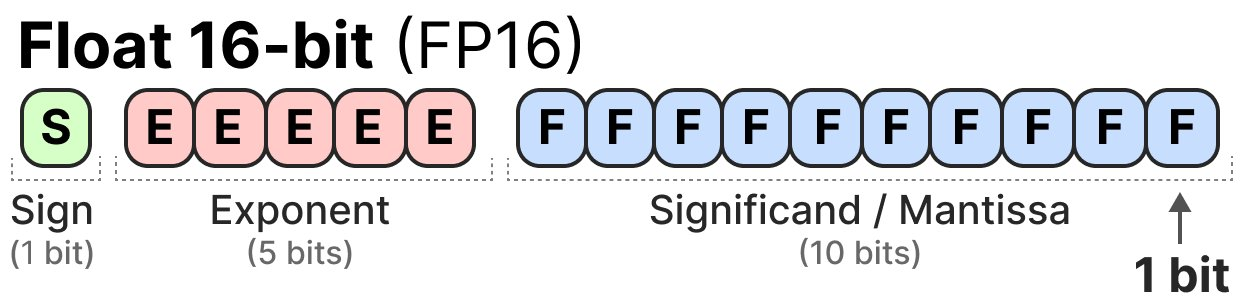

Together, these three components can be used to calculate a value from a set of bits:

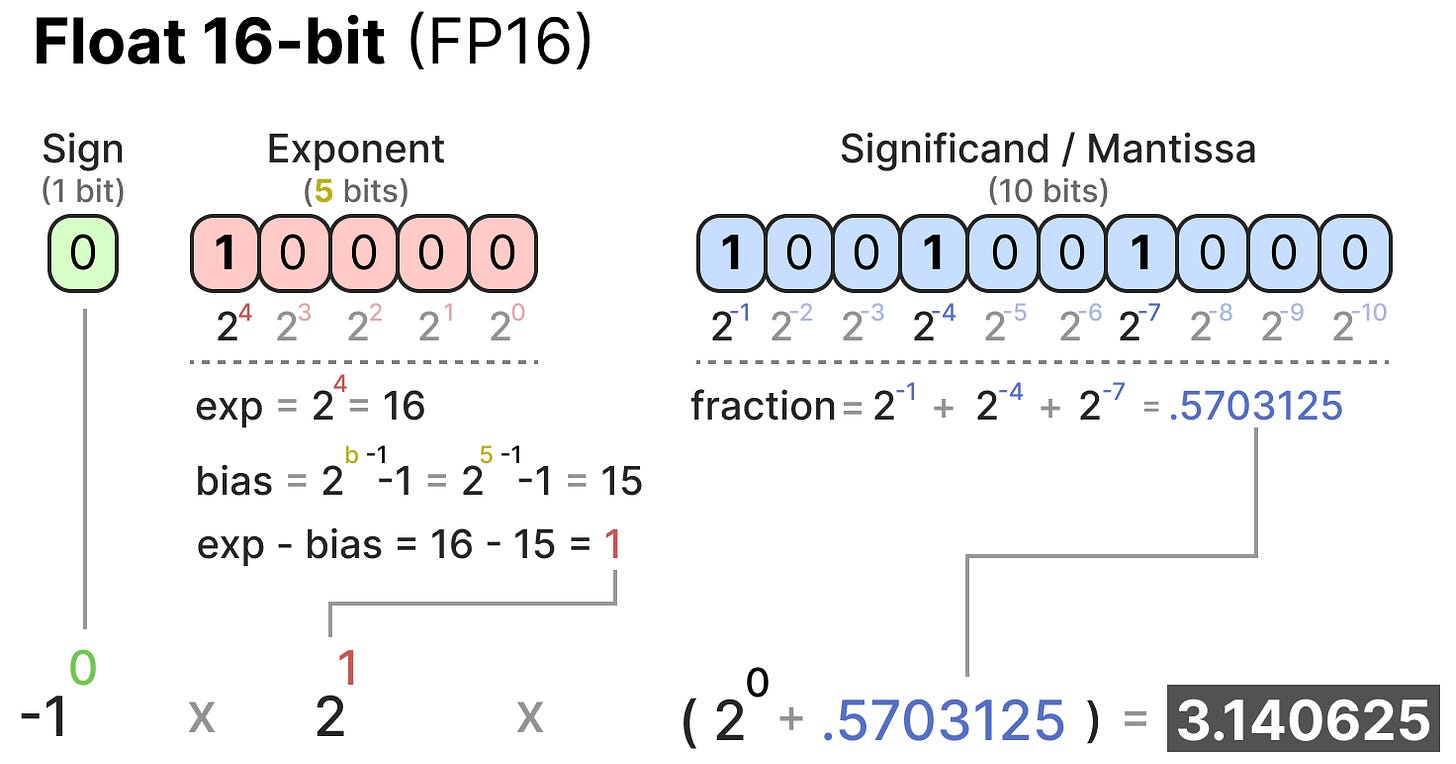

The more bits we use to represent a value, the more precise it generally is:

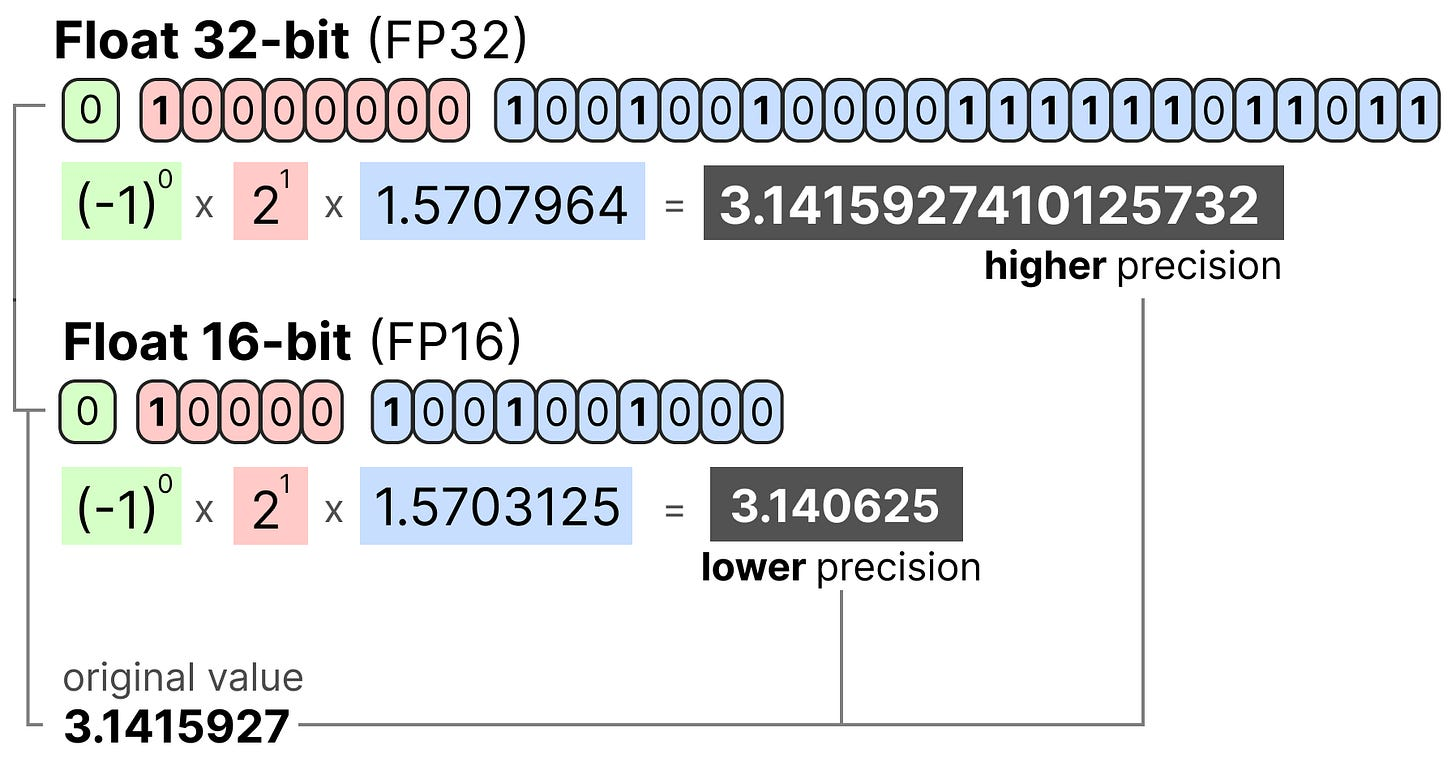


### Memory Constraints

The more bits we have available, the larger the range of values that can be represented.

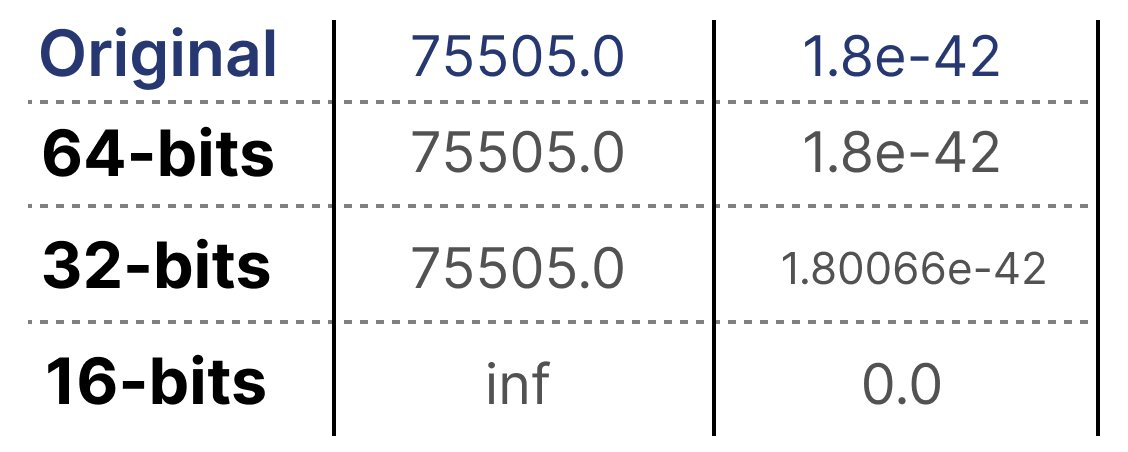

The interval of representable numbers is called the **dynamic range**, whereas the distance between two neighboring values is called the **precision**.

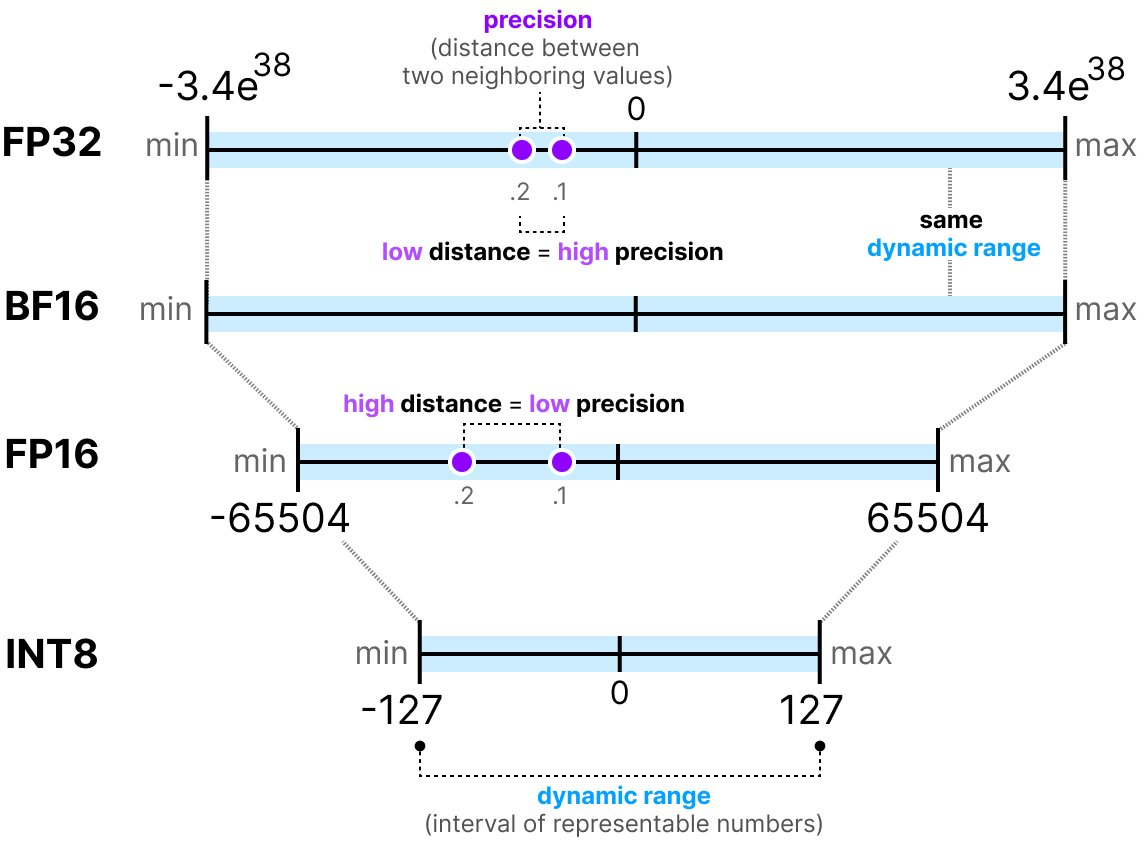

Since there are 8 bits in a byte of memory, we can estimate memory requirements:

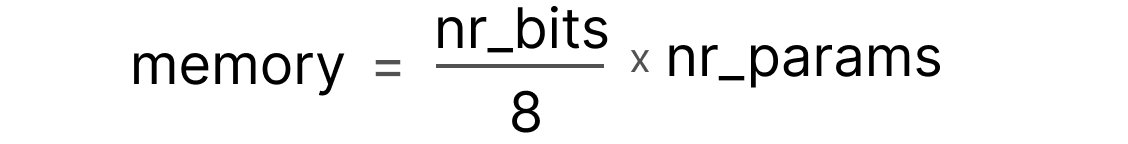

Now assume we have a model with 70 billion parameters. In FP32 (*full-precision*), this would require **280 GB** of memory just to load the model.

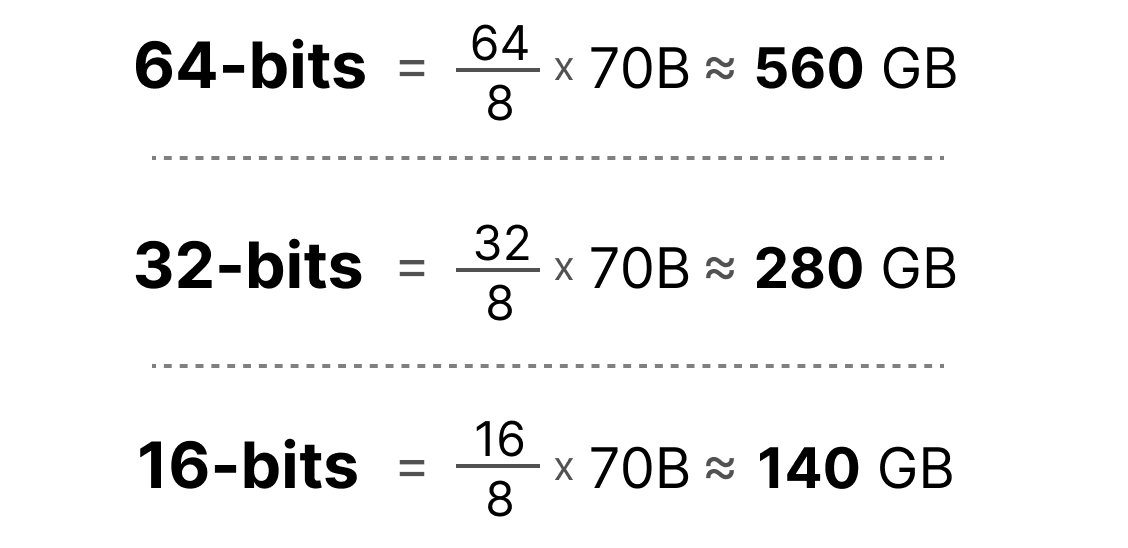

We want to reduce the number of bits while maintaining accuracy — this is where **quantization** comes in.


---
## Introduction to Quantization

Quantization aims to reduce the precision of a model's parameters from higher bit-widths (like 32-bit floating point) to lower bit-widths (like 8-bit integers).





There is often some loss of precision when reducing the number of bits. To illustrate, consider reducing the number of colors in an image:

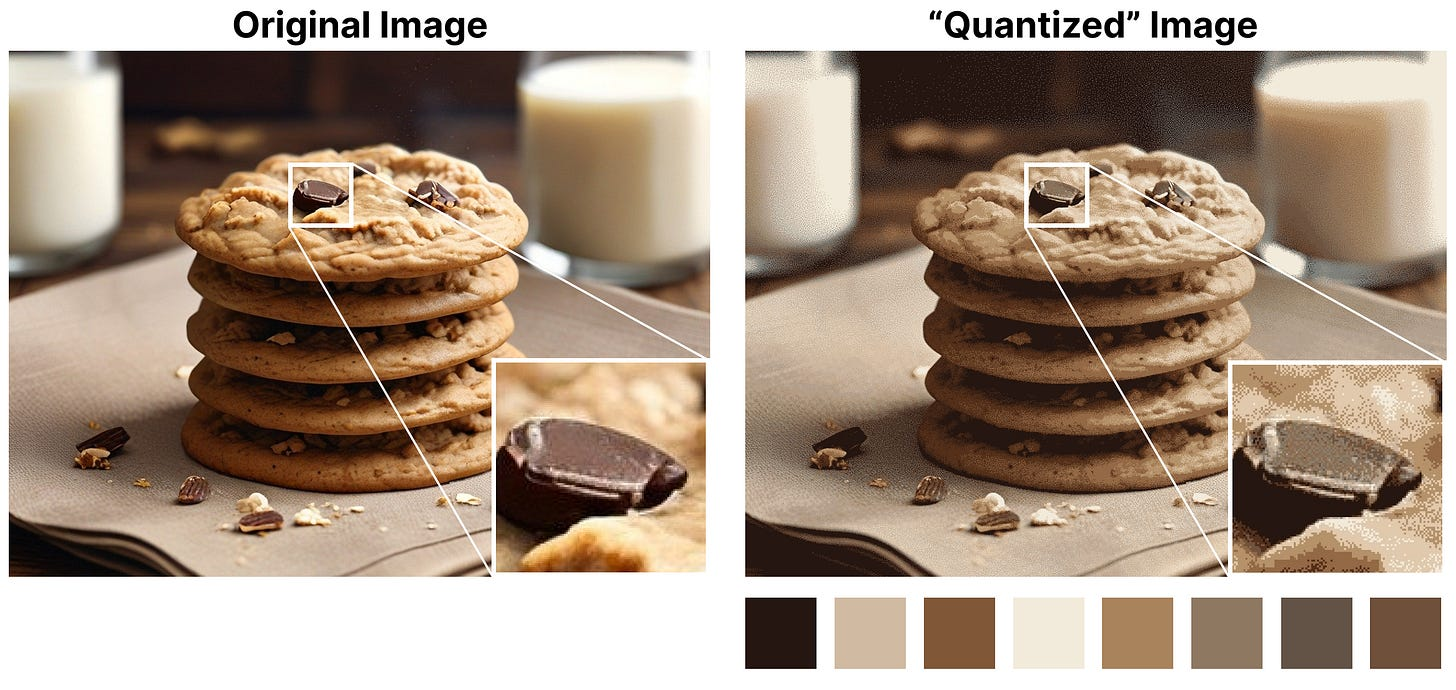

The main goal of quantization is to reduce the number of bits needed to represent the original parameters while preserving their precision as best as possible.


### Common Data Types

#### FP16
Going from 32-bit to 16-bit (*half precision* or FP16):

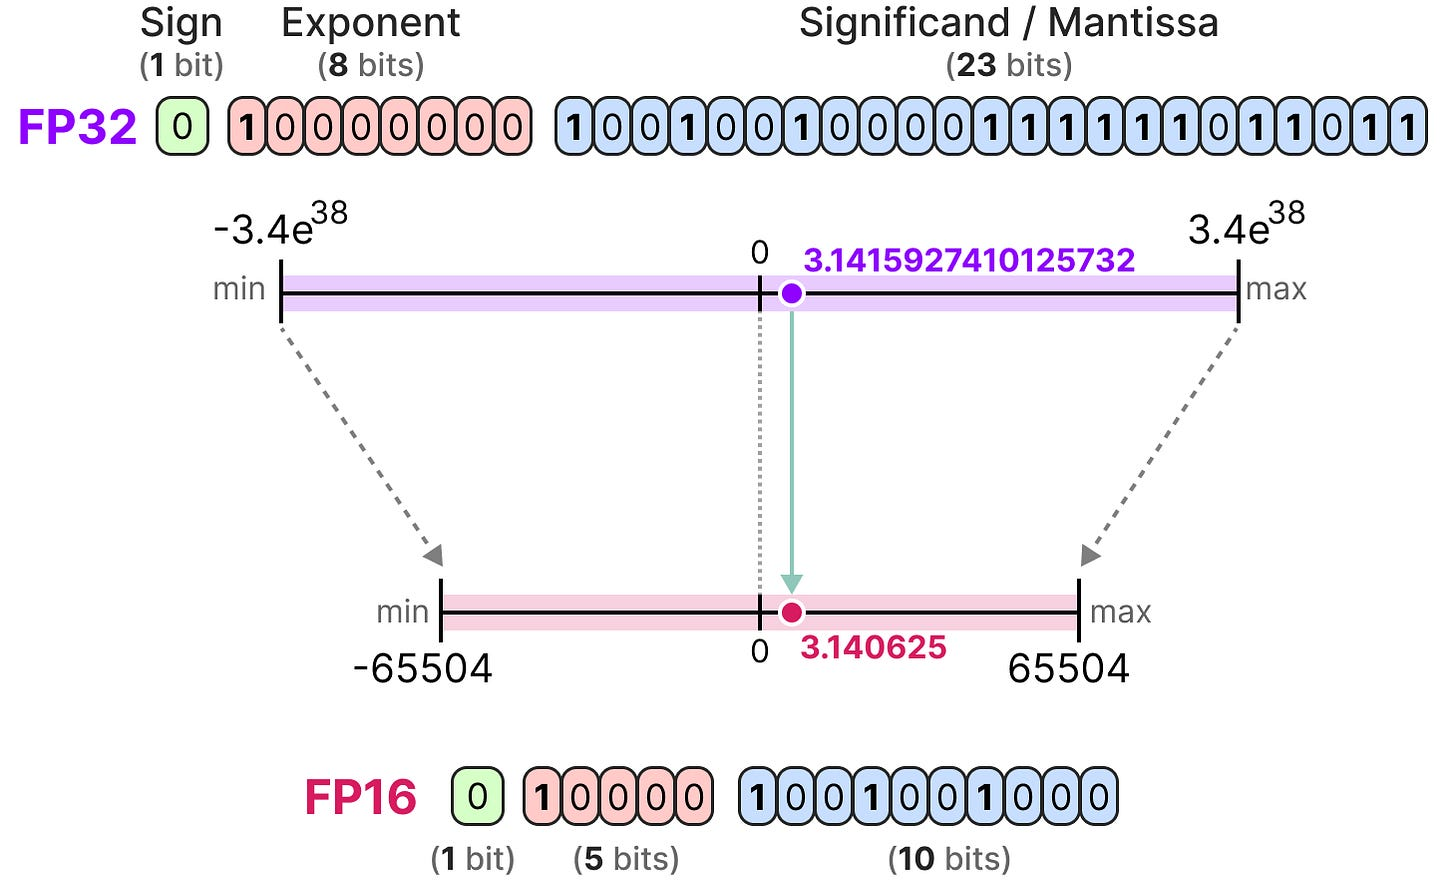

#### BF16
To get a similar range as FP32, *bfloat 16* was introduced as a type of "truncated FP32":

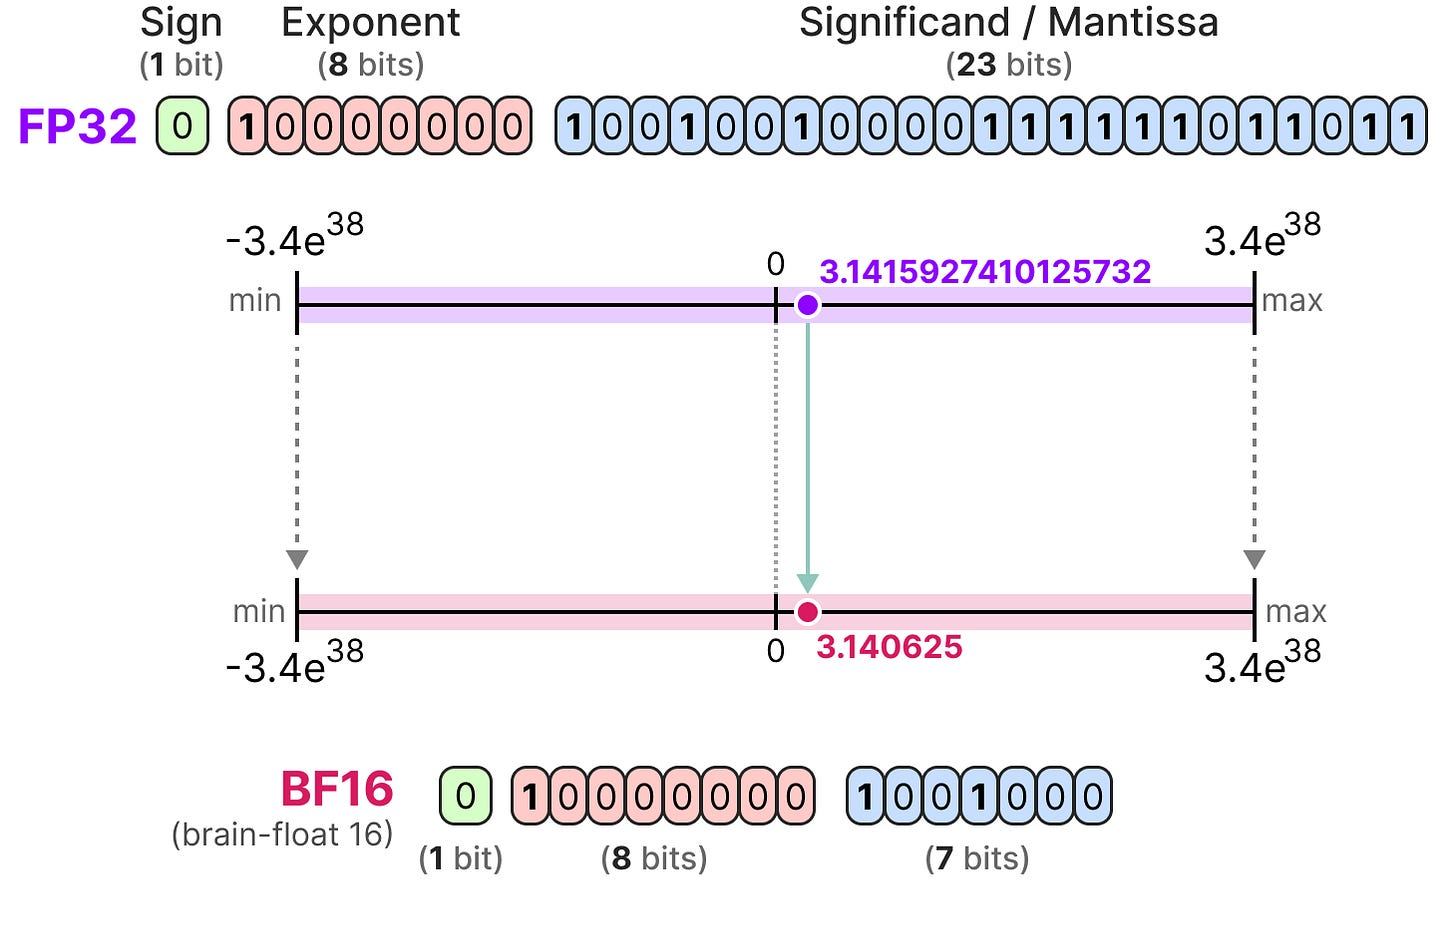

BF16 uses the same number of bits as FP16 but can take a wider range of values.

#### INT8
Going from FP32 to INT8 (only 8 bits) results in a quarter of the original bits:

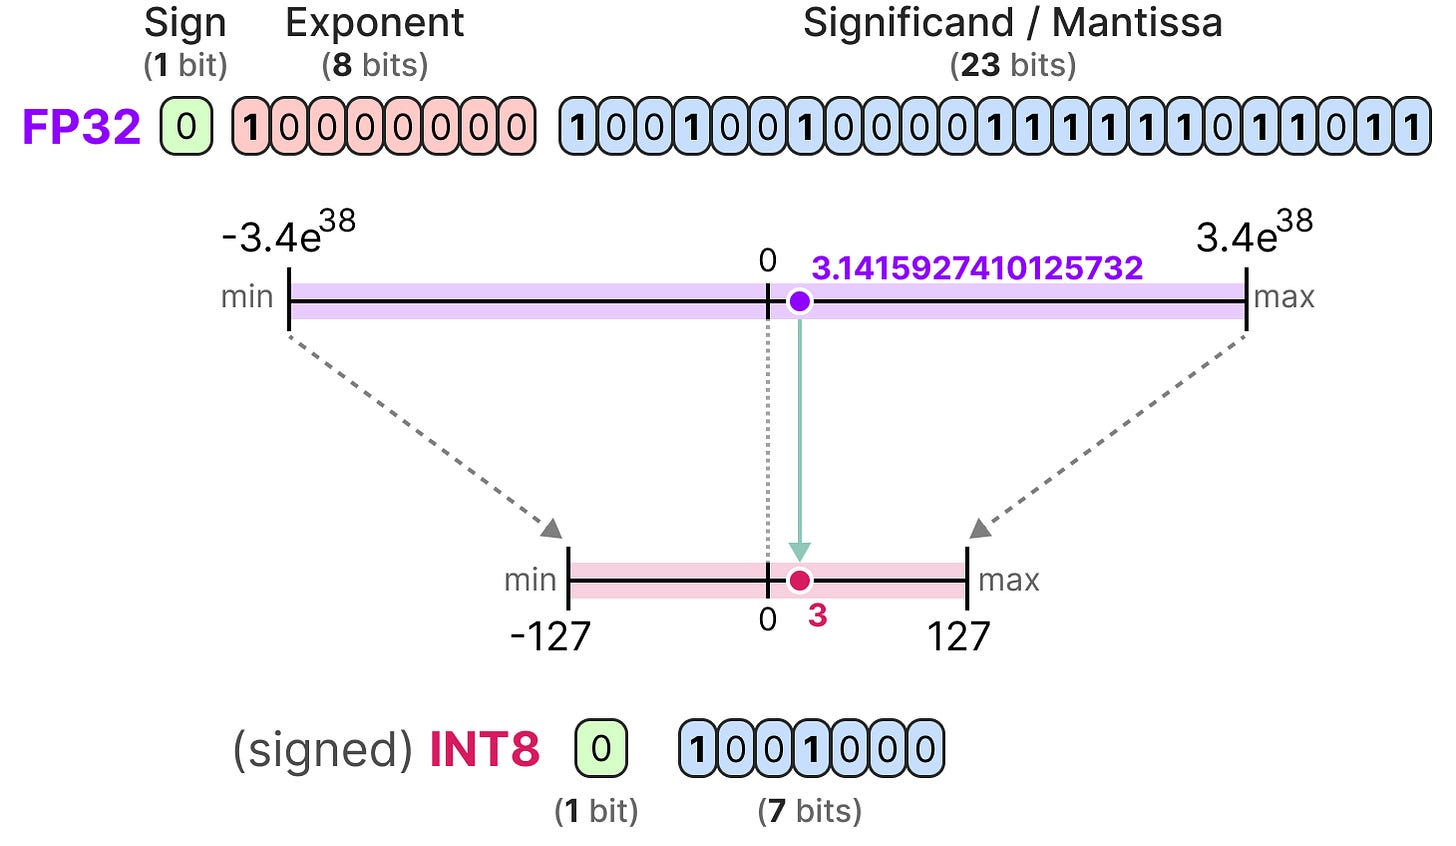

In practice, we do not need to map the entire FP32 range into INT8. We merely need to map the range of our data (the model's parameters). Common mapping methods are **symmetric** and **asymmetric** quantization.


## FP16, BF16, and Mixed Precision Training

### The bit layout

Both FP16 and BF16 use 16 bits, but allocate them differently:

| Format | Sign | Exponent | Fraction | Total |
|--------|------|----------|----------|-------|
| FP32   | 1    | 8        | 23       | 32    |
| FP16   | 1    | 5        | 10       | 16    |
| BF16   | 1    | 8        | 7        | 16    |

The exponent controls the **dynamic range** (how large or small a number can be). The fraction controls the **precision** (how many decimal places).

### FP16: more precision, smaller range

FP16 has 10 fraction bits (more precise) but only 5 exponent bits. This gives it a max value of ~65,504. That sounds large, but during training, gradient values and loss values can easily exceed this — causing **overflow to infinity**. Values smaller than ~6×10⁻⁸ become exactly zero — this is **underflow**.

### BF16: less precision, same range as FP32

BF16 keeps all 8 exponent bits from FP32, giving it the exact same dynamic range: ±3.4×10³⁸. The tradeoff is only 7 fraction bits, so individual values are less precise. But in practice this matters far less than overflow/underflow.

### Why BF16 is better for training

The core reason: **gradient values during backpropagation span a huge range.** Some gradients are very large (early layers, loss spikes), some are extremely small (deep layers, near convergence). BF16 handles both extremes without overflow or underflow because it has FP32's range.

With FP16, you need **loss scaling** — artificially multiplying the loss by a large factor before backprop (so small gradients don't underflow), then dividing after. This adds complexity, can cause instability, and sometimes still fails on certain architectures. BF16 simply doesn't need it.

In short:

| Issue | FP16 | BF16 |
|-------|------|------|
| Large gradients overflow? | Yes (max ~65K) | No (max ~3.4e38) |
| Small gradients underflow? | Yes | Rarely |
| Needs loss scaling? | Yes | No |
| Precision per value | Higher (10 frac bits) | Lower (7 frac bits) |
| Training stability | Fragile | Robust |

The lower per-value precision of BF16 is not a problem because neural network training is inherently noisy (stochastic gradients, dropout, data augmentation). The model doesn't need 10 bits of fraction precision — it needs to not blow up.

### Mixed Precision Training

Mixed precision uses 16-bit (FP16 or BF16) for most operations but keeps a **master copy of weights in FP32**. The flow:

1. **Forward pass:** Use FP16/BF16 weights and activations (fast, low memory)
2. **Backward pass:** Compute gradients in FP16/BF16
3. **Weight update:** Convert gradients to FP32, apply to the FP32 master weights
4. **Next iteration:** Cast FP32 master weights back to FP16/BF16

Why the FP32 master copy? Weight updates are often tiny (learning rate × gradient). In 16-bit, a small update to a large weight can round to zero — the weight never changes. The FP32 copy accumulates these small updates accurately.

**With BF16 mixed precision**, you skip the loss scaling entirely. This is why most modern frameworks (PyTorch FSDP, DeepSpeed, HuggingFace Accelerate) default to BF16 when the hardware supports it (A100, H100, and newer GPUs).

### One-liner

> FP16 has better precision but can overflow/underflow during training. BF16 trades some precision for FP32's full range, making training stable without loss scaling. That's why BF16 is the default for modern LLM training.

### Symmetric Quantization

In symmetric quantization, the range of the original floating-point values is mapped to a symmetric range around zero. The quantized value for zero in FP32 is exactly zero in the quantized space.

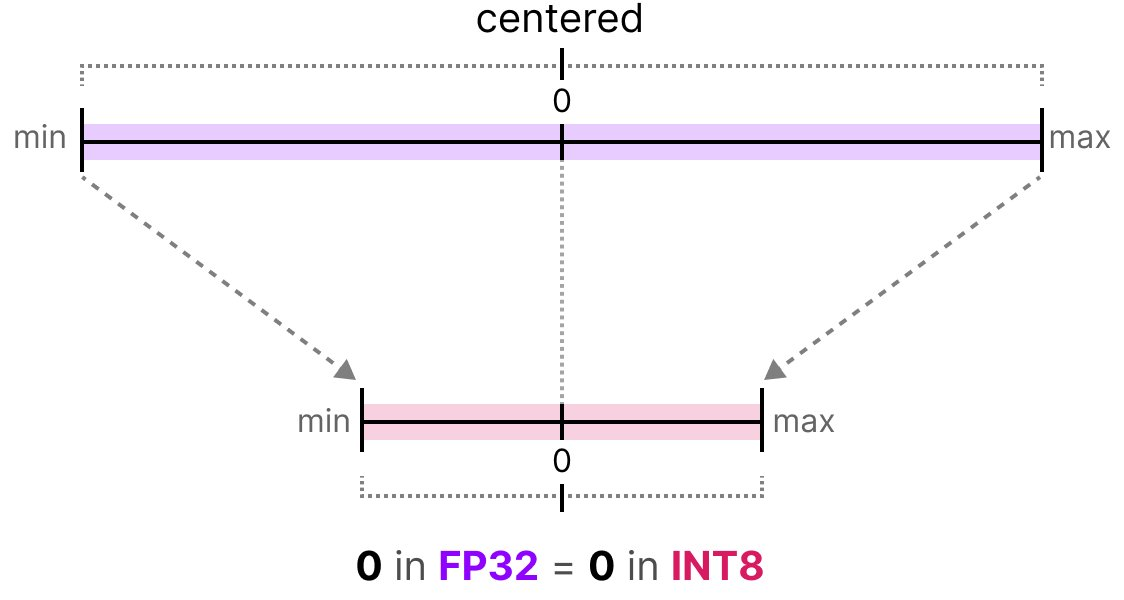

A common form is **absolute maximum (absmax)** quantization. We take the highest absolute value (**α**) as the range for the linear mapping.

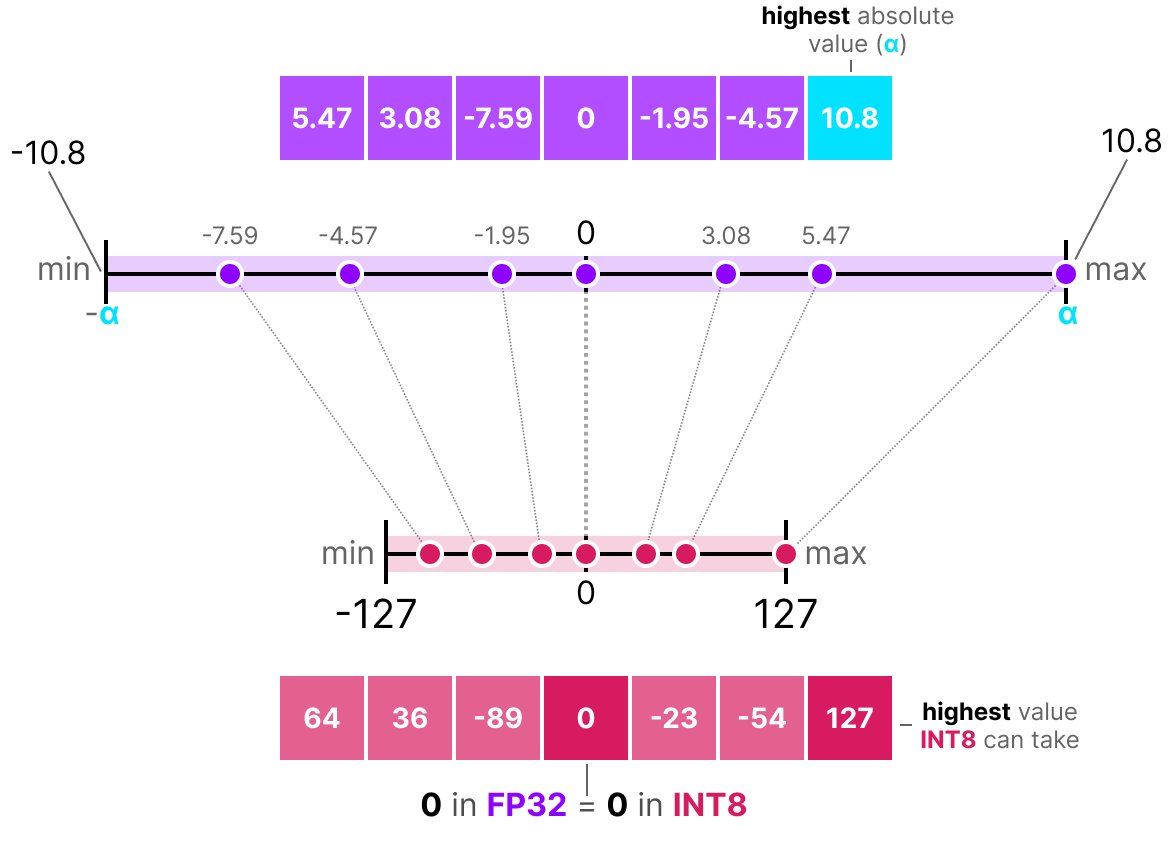

The scale factor and quantization formula:

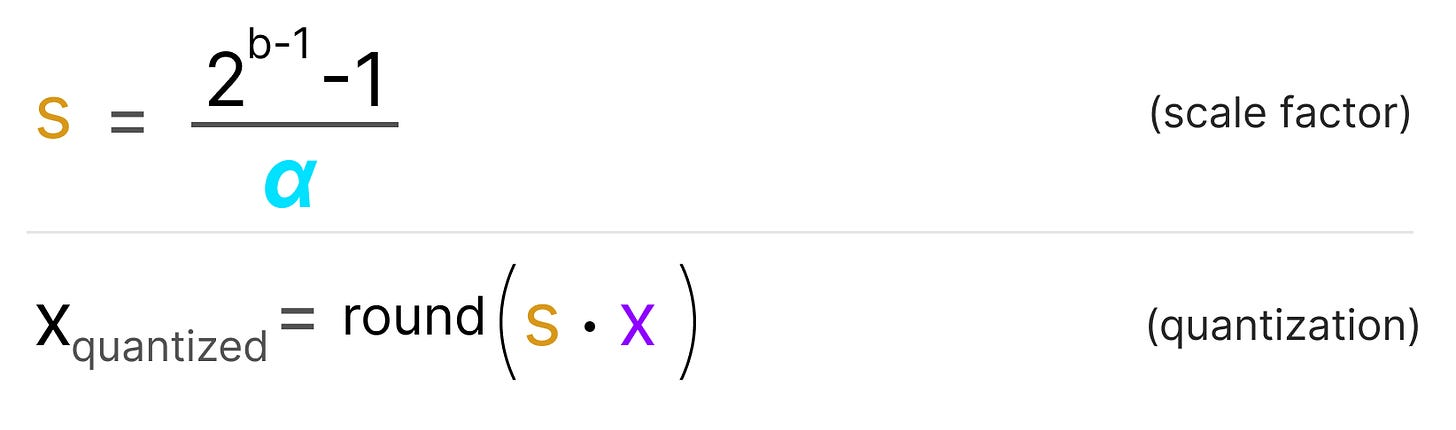

Filling in concrete values:

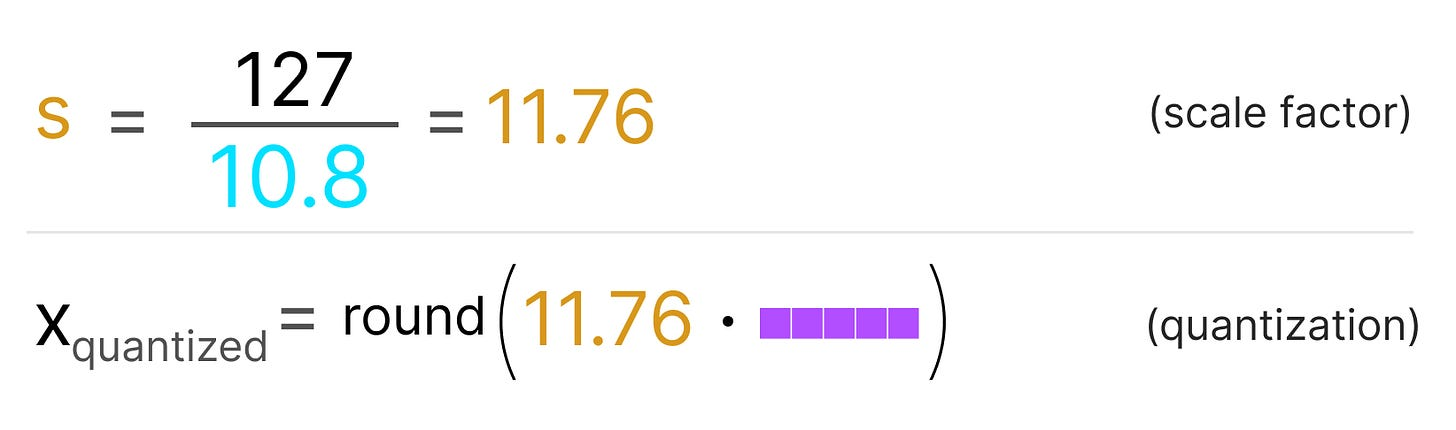

To retrieve the original FP32 values, we use the scale factor to **dequantize**:

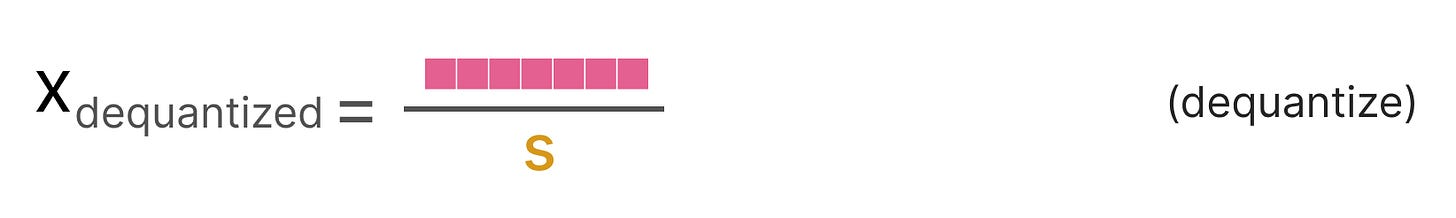

The full quantize-then-dequantize roundtrip:

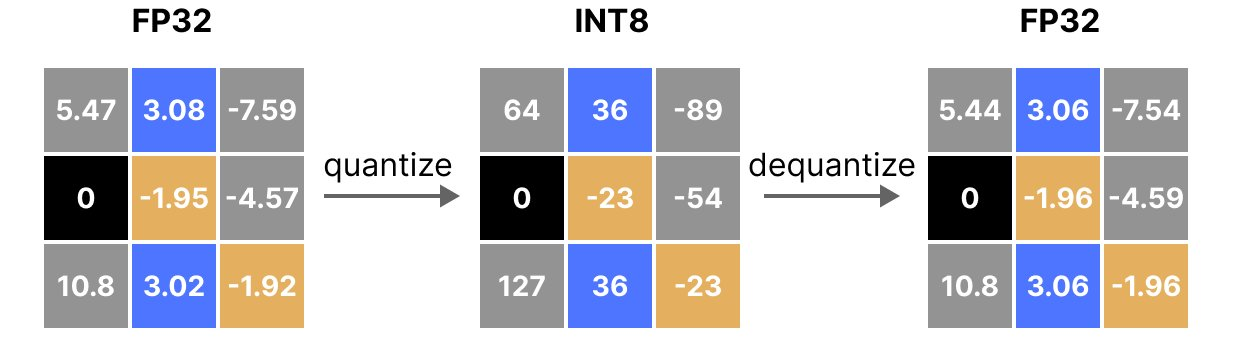

Some values get assigned to the same INT8 value. When dequantized, they lose precision. This is the **quantization error**:

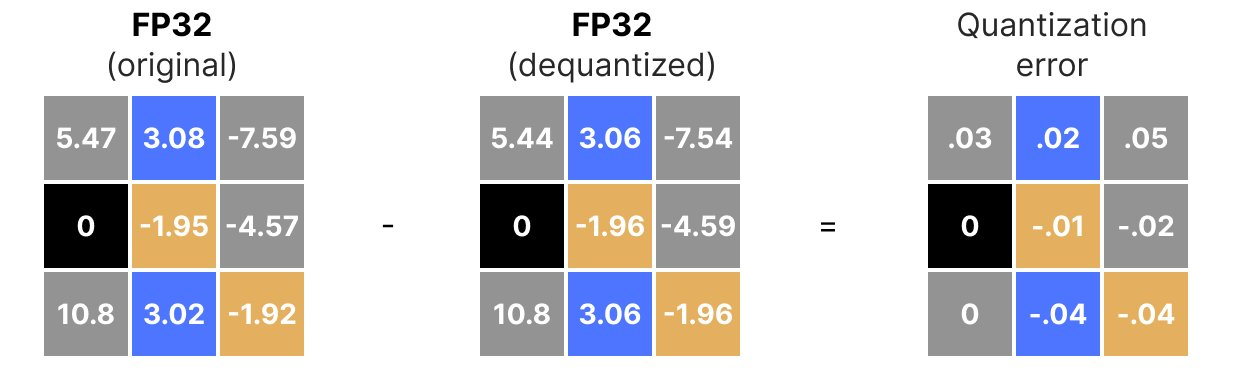


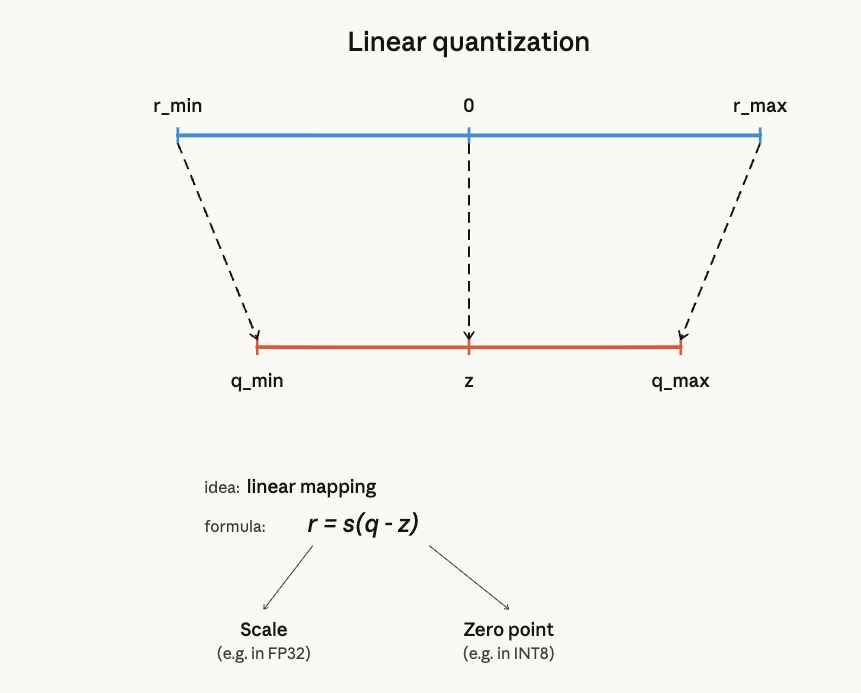

### Asymmetric Quantization

Asymmetric quantization is not symmetric around zero. Instead, it maps the minimum (**β**) and maximum (**α**) of the float range to the min and max of the quantized range. This method is called **zero-point quantization**.

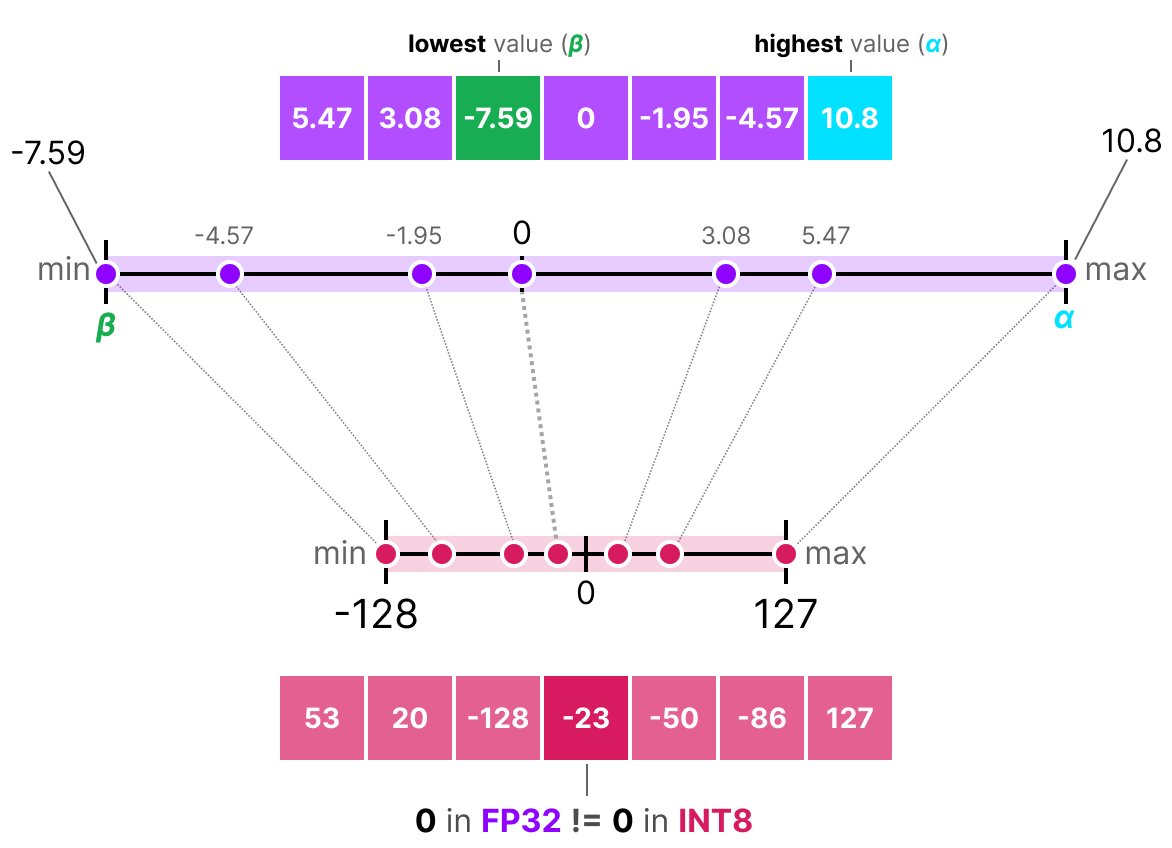

We need to calculate both a **zero-point** and a **scale factor**:

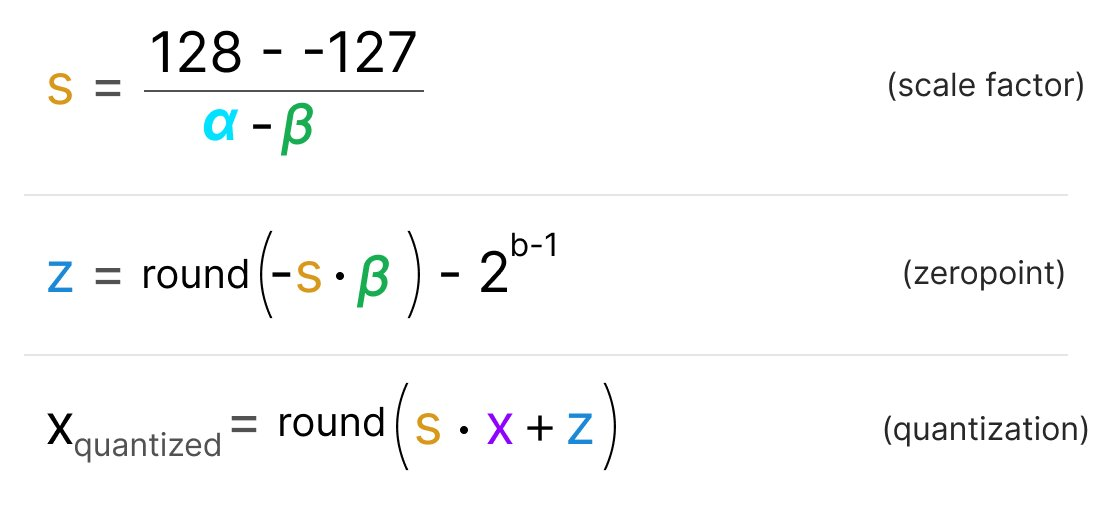

Filling in the values:

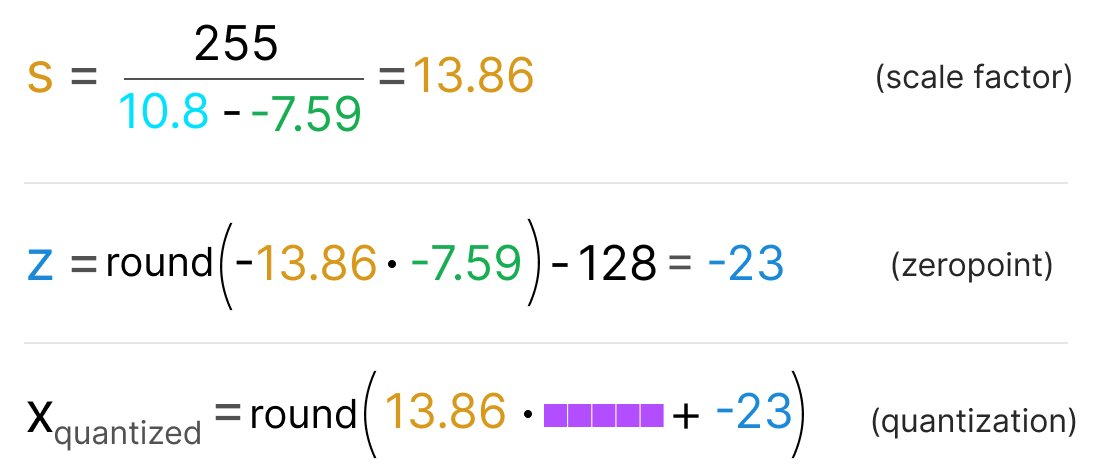

To dequantize, we need both the scale factor and the zero-point:

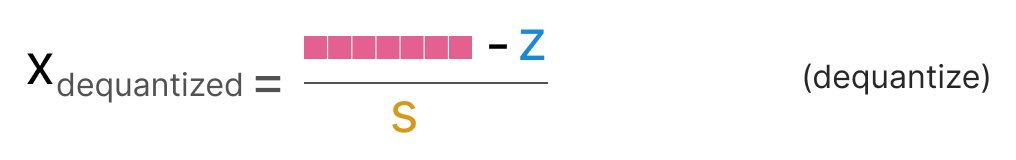

Side-by-side comparison of symmetric vs asymmetric:

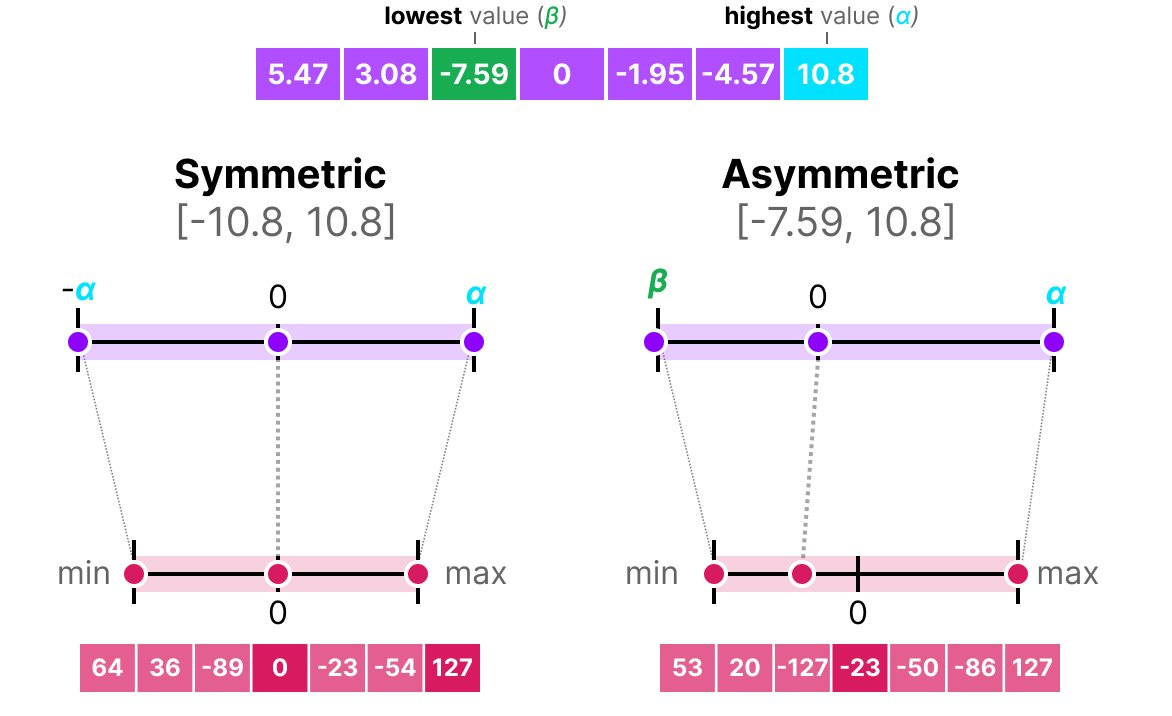


### Linear Quantization — Example with 8 bit

Let us walk through a concrete example of asymmetric (zero-point) linear quantization on a 3×3 tensor.

**Original tensor (FP32):**

|  |  |  |
|------|-------|-------|
| 191.6 | -13.5 | 728.6 |
| 92.14 | 295.5 | -184  |
| 0     | 684.6 | 245.5 |

**Step 1: Compute scale and zero point**

From the tensor, the real-valued range is:

- r_min = -184
- r_max = 728.6

For INT8, the quantized range is [-128, 127]. The scale and zero point are:

```
s = (r_max - r_min) / (q_max - q_min)
  = (728.6 - (-184)) / (127 - (-128))
  = 912.6 / 255
  ≈ 3.58

z = q_min - (r_min / s)
  = -128 - (-184 / 3.58)
  = -128 + 51.4
  ≈ -77
```

**Step 2: Quantize (FP32 → INT8)**

Using the formula: `q = clamp(round(x / s + z), -128, 127)`

**Quantized tensor (INT8):**

|  |  |  |
|-----|------|------|
| -23 | -81  | 127  |
| -51 | 6    | -128 |
| -77 | 114  | -8   |

**Step 3: Dequantize (INT8 → FP32)**

Using the formula: `r = (q - z) × s`

For example, the first element:

```
r = (-23 - (-77)) × 3.58
  = 54 × 3.58
  = 193.32
```

The original value was 191.6 — we get 193.32 after the roundtrip. The difference (1.72) is the **quantization error** for that element.

**The general dequantization formula:**

```
r       =  (  q   -   z  )  ×   s
FP32       int8     int8       FP32
```

Notice that the zero point `z = -77` appears in the quantized tensor itself (for the original value 0). This is expected — in zero-point quantization, the real value 0 maps to the zero point in the quantized space.

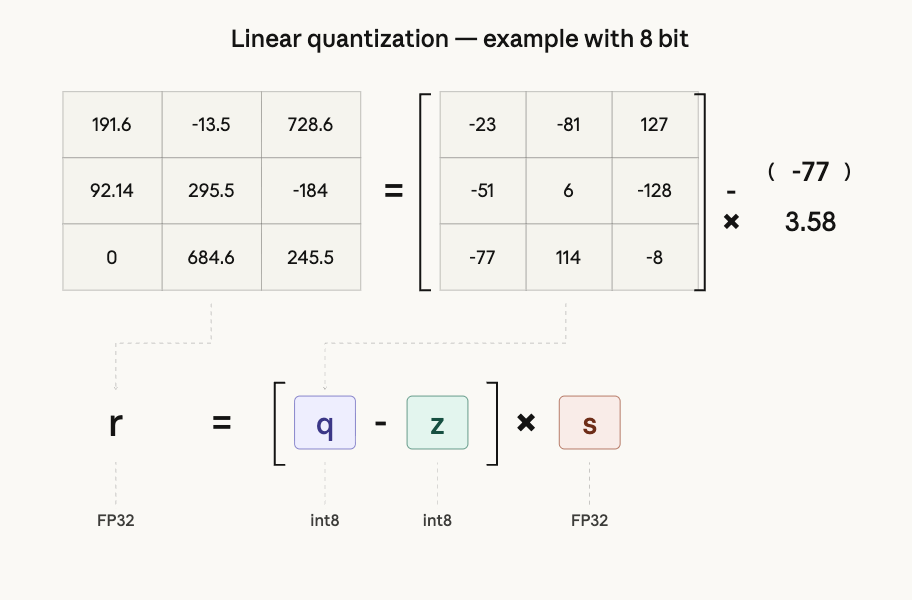

---
## Implementing Linear Quantization in PyTorch

Now let us implement the concepts above from scratch.


In [ ]:
import torch


### Quantize and Dequantize a Tensor (given scale and zero point)


In [ ]:
def linear_q_with_scale_and_zero_point(
    tensor, scale, zero_point, dtype=torch.int8):
    """Quantize a floating-point tensor to integer representation."""

    scaled_and_shifted_tensor = tensor / scale + zero_point

    rounded_tensor = torch.round(scaled_and_shifted_tensor)

    q_min = torch.iinfo(dtype).min
    q_max = torch.iinfo(dtype).max

    q_tensor = rounded_tensor.clamp(q_min, q_max).to(dtype)

    return q_tensor


In [ ]:
def linear_dequantization(quantized_tensor, scale, zero_point):
    """Dequantize an integer tensor back to floating point."""
    return scale * (quantized_tensor.float() - zero_point)


In [ ]:
### a dummy tensor to test the implementation
test_tensor = torch.tensor(
    [[191.6, -13.5, 728.6],
     [92.14, 295.5,  -184],
     [0,     684.6, 245.5]]
)

### these are random values for "scale" and "zero_point"
scale = 3.5
zero_point = -70

quantized_tensor = linear_q_with_scale_and_zero_point(
    test_tensor, scale, zero_point)

print("Quantized (INT8):")
print(quantized_tensor)
print(f"\nDtype: {quantized_tensor.dtype}")


Quantized (INT8):
tensor([[ -15,  -74,  127],
        [ -44,   14, -123],
        [ -70,  126,    0]], dtype=torch.int8)

Dtype: torch.int8


In [ ]:
dequantized_tensor = linear_dequantization(
    quantized_tensor, scale, zero_point)

print("Original:")
print(test_tensor)
print("\nDequantized:")
print(dequantized_tensor)


Original:
tensor([[ 191.6000,  -13.5000,  728.6000],
        [  92.1400,  295.5000, -184.0000],
        [   0.0000,  684.6000,  245.5000]])

Dequantized:
tensor([[ 192.5000,  -14.0000,  689.5000],
        [  91.0000,  294.0000, -185.5000],
        [   0.0000,  686.0000,  245.0000]])


### Quantization Error


In [ ]:
# Element-wise error
print("Difference (Original - Dequantized):")
print(dequantized_tensor - test_tensor)

print("\nSquared error:")
print((dequantized_tensor - test_tensor).square())

# Overall error via MSE
mse = (dequantized_tensor - test_tensor).square().mean()
print(f"\nQuantization Error (MSE): {mse.item():.4f}")


Difference (Original - Dequantized):
tensor([[  0.9000,  -0.5000, -39.1000],
        [ -1.1400,  -1.5000,  -1.5000],
        [  0.0000,   1.4000,  -0.5000]])

Squared error:
tensor([[8.0999e-01, 2.5000e-01, 1.5288e+03],
        [1.2996e+00, 2.2500e+00, 2.2500e+00],
        [0.0000e+00, 1.9601e+00, 2.5000e-01]])

Quantization Error (MSE): 170.8753


The error is large because we used arbitrary `scale` and `zero_point` values. Next, we compute them properly.

### Computing Scale and Zero Point


In [ ]:
def get_q_scale_and_zero_point(tensor, dtype=torch.int8):
    """Compute optimal scale and zero point for asymmetric quantization."""

    q_min, q_max = torch.iinfo(dtype).min, torch.iinfo(dtype).max
    r_min, r_max = tensor.min().item(), tensor.max().item()

    scale = (r_max - r_min) / (q_max - q_min)

    zero_point = q_min - (r_min / scale)

    # clip the zero_point to fall in [quantized_min, quantized_max]
    if zero_point < q_min:
        zero_point = q_min
    elif zero_point > q_max:
        zero_point = q_max
    else:
        # round and cast to int
        zero_point = int(round(zero_point))

    return scale, zero_point


In [ ]:
scale, zero_point = get_q_scale_and_zero_point(test_tensor)
print(f"Computed scale:      {scale:.6f}")
print(f"Computed zero_point: {zero_point}")


Computed scale:      3.578823
Computed zero_point: -77


In [ ]:
# Quantize with computed parameters
quantized_tensor = linear_q_with_scale_and_zero_point(
    test_tensor, scale, zero_point)

dequantized_tensor = linear_dequantization(
    quantized_tensor, scale, zero_point)

mse = (dequantized_tensor - test_tensor).square().mean()

print(f"MSE with computed params: {mse.item():.4f}")
print(f"\nOriginal:\n{test_tensor}")
print(f"\nDequantized:\n{dequantized_tensor}")


MSE with computed params: 1.5730

Original:
tensor([[ 191.6000,  -13.5000,  728.6000],
        [  92.1400,  295.5000, -184.0000],
        [   0.0000,  684.6000,  245.5000]])

Dequantized:
tensor([[ 193.2565,  -14.3153,  730.0800],
        [  93.0494,  297.0423, -182.5200],
        [   0.0000,  683.5552,  246.9388]])


### Complete Linear Quantizer


In [ ]:
def linear_quantization(tensor, dtype=torch.int8):
    """End-to-end linear quantization: compute params and quantize."""
    scale, zero_point = get_q_scale_and_zero_point(tensor, dtype=dtype)

    quantized_tensor = linear_q_with_scale_and_zero_point(
        tensor, scale, zero_point, dtype=dtype)

    return quantized_tensor, scale, zero_point


In [ ]:
# Test on a random tensor
r_tensor = torch.randn((4, 4))
print("Original tensor:")
print(r_tensor)

quantized_tensor, scale, zero_point = linear_quantization(r_tensor)
print(f"\nQuantized tensor (INT8):")
print(quantized_tensor)
print(f"\nScale: {scale:.6f}, Zero Point: {zero_point}")

dequantized_tensor = linear_dequantization(quantized_tensor, scale, zero_point)
mse = (dequantized_tensor - r_tensor).square().mean()
print(f"\nQuantization Error (MSE): {mse.item():.6f}")


Original tensor:
tensor([[ 1.9269,  1.4873,  0.9007, -2.1055],
        [ 0.6784, -1.2345, -0.0431, -1.6047],
        [-0.7521,  1.6487, -0.3925, -1.4036],
        [-0.7279, -0.5594, -0.7688,  0.7624]])

Quantized tensor (INT8):
tensor([[ 127,   99,   62, -128],
        [  48,  -73,    2,  -96],
        [ -43,  109,  -20,  -84],
        [ -41,  -30,  -44,   53]], dtype=torch.int8)

Scale: 0.015813, Zero Point: 5

Quantization Error (MSE): 0.000016


### Symmetric Quantization (absmax) — Code


In [ ]:
def get_q_scale_symmetric(tensor, dtype=torch.int8):
    """Compute scale for symmetric (absmax) quantization."""
    q_max = torch.iinfo(dtype).max  # 127 for int8
    alpha = tensor.abs().max().item()
    scale = alpha / q_max
    return scale


def linear_q_symmetric(tensor, dtype=torch.int8):
    """Symmetric quantization using absmax."""
    scale = get_q_scale_symmetric(tensor, dtype)
    quantized_tensor = linear_q_with_scale_and_zero_point(
        tensor, scale, zero_point=0, dtype=dtype)
    return quantized_tensor, scale


In [ ]:
# Symmetric quantization on test_tensor
quantized_tensor, scale = linear_q_symmetric(test_tensor)
dequantized_tensor = linear_dequantization(quantized_tensor, scale, 0)
mse = (dequantized_tensor - test_tensor).square().mean()

print(f"Scale (symmetric): {scale:.6f}")
print(f"Quantization Error (MSE): {mse.item():.4f}")
print(f"\nOriginal:\n{test_tensor}")
print(f"\nDequantized:\n{dequantized_tensor}")


Scale (symmetric): 5.737008
Quantization Error (MSE): 2.5092

Original:
tensor([[ 191.6000,  -13.5000,  728.6000],
        [  92.1400,  295.5000, -184.0000],
        [   0.0000,  684.6000,  245.5000]])

Dequantized:
tensor([[ 189.3213,  -11.4740,  728.6000],
        [  91.7921,  298.3244, -183.5842],
        [   0.0000,  682.7039,  246.6913]])


---
### Range Mapping and Clipping

Outliers cause problems. If one value is much larger than all others:

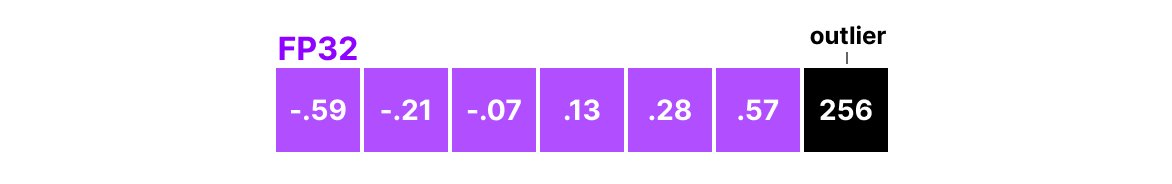

If we map the full range, all smaller values lose their differentiating factor:


**Clipping** sets a tighter dynamic range so that outliers get clamped:

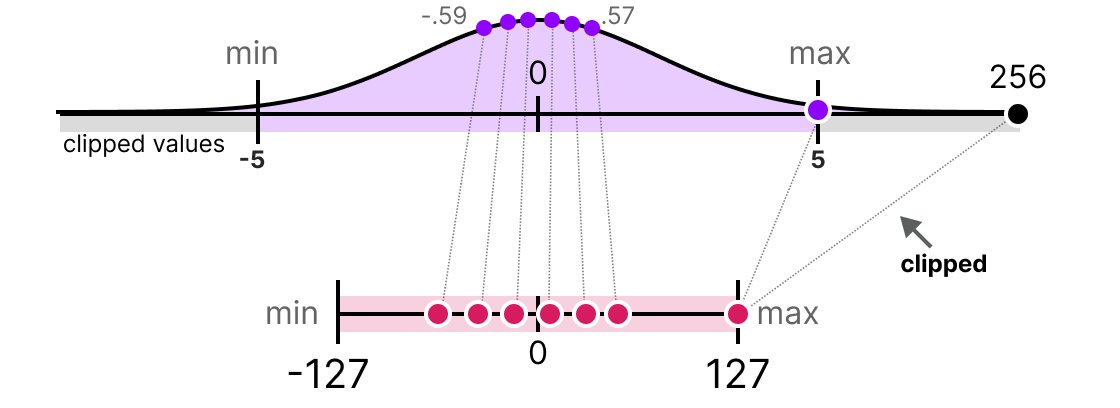


### Calibration

The process of selecting the optimal clipping range is known as **calibration**.

#### Weights (and Biases)

Weights and biases are *static* — known before running the model.

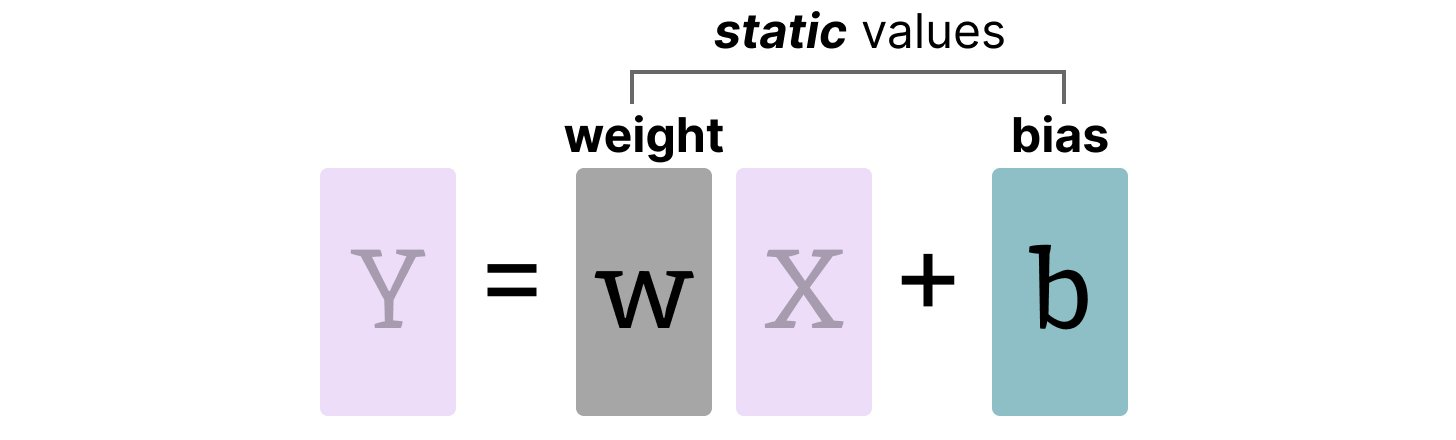

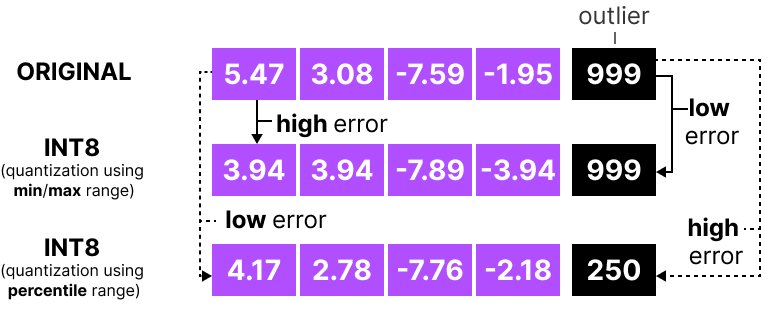

#### Activations

Activations are *dynamic* — they vary with each input during inference.

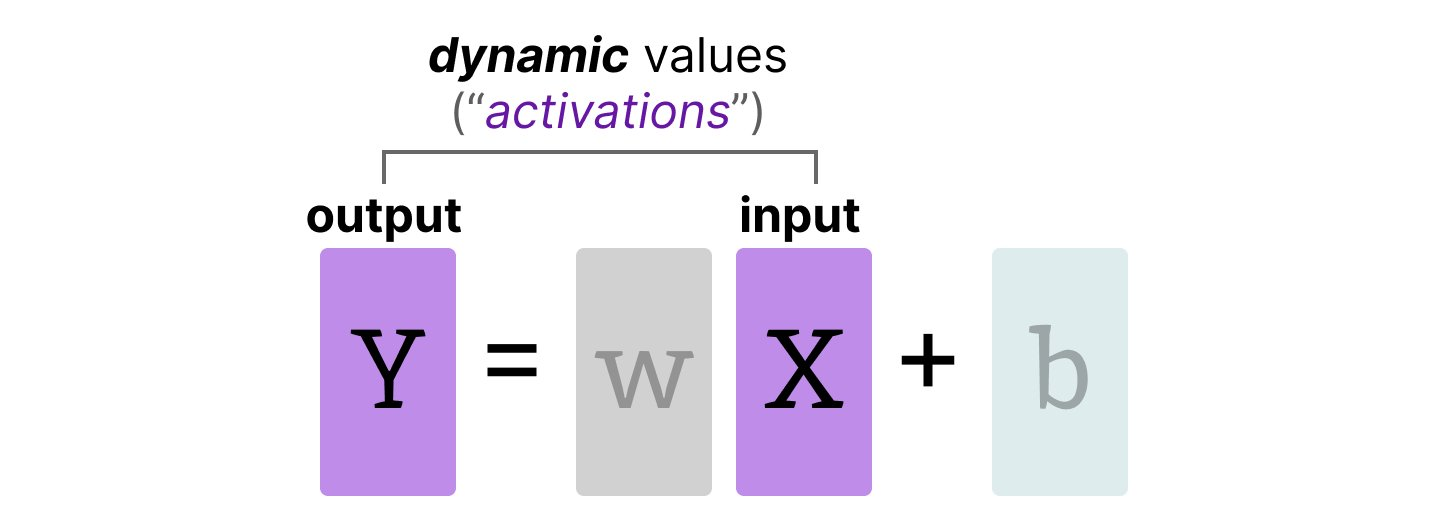

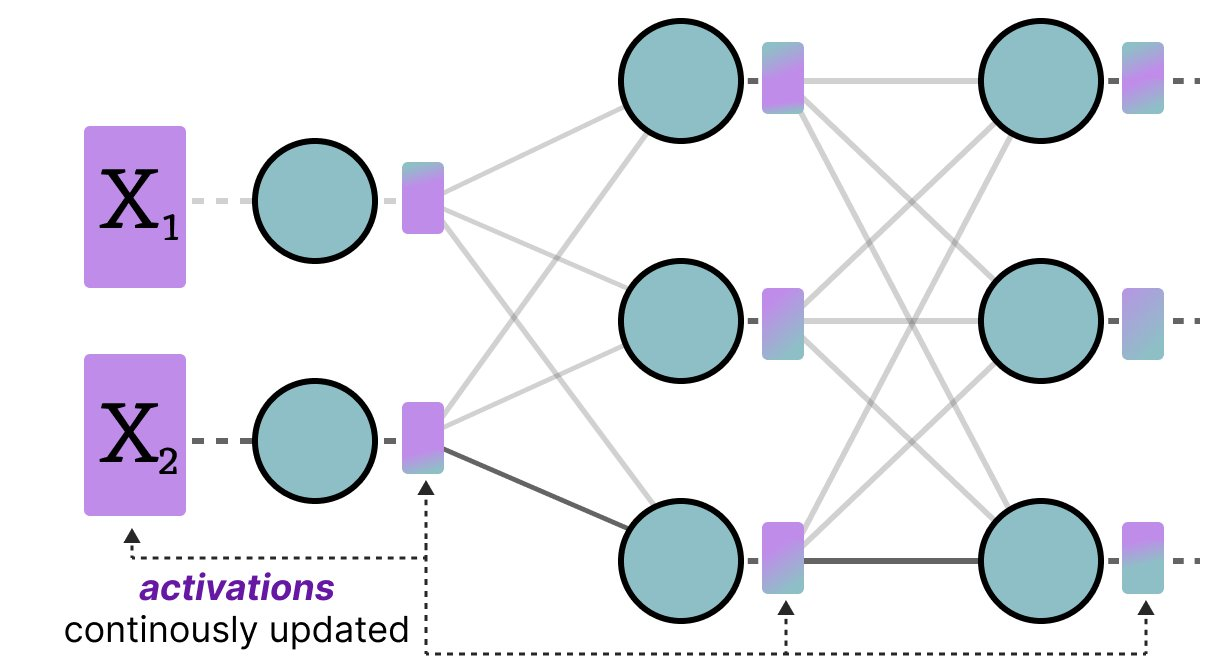

Broadly, there are two methods: **Post-Training Quantization (PTQ)** and **Quantization-Aware Training (QAT)**.


### Beyond Weights: Activations and the KV Cache

In a Large Language Model, two major sources of memory consumption beyond weights are **activations** and the **Key-Value (KV) Cache**.

- **Activations** are the intermediate numerical values computed during each forward pass of the model.
- **The KV Cache** is an optimization technique used during autoregressive generation. It stores the Key (K) and Value (V) tensors for previous tokens in a sequence to avoid costly recomputation. For long sequences, this cache can grow to several gigabytes.

Unlike model weights, which are static after training, both activations and the KV cache are **dynamic**. Their values are generated at runtime and change based on the specific input provided to the model. This means we cannot pre-calculate their quantization parameters (scale and zero-point) ahead of time.

### Calibration for Dynamic Values

The solution is a process called **calibration**. Calibration allows us to find a representative range for these dynamic values. The process involves four steps:

**Step 1 — Prepare a calibration dataset:** Select a small but representative sample of data (e.g., 100–200 examples) that reflects the kind of inputs the model will see in production.

**Step 2 — Run inference:** Feed the calibration dataset through the model.

**Step 3 — Collect statistics:** During the inference passes, record the minimum and maximum floating-point values observed for each activation tensor you intend to quantize.

**Step 4 — Calculate scale and zero-point:** Using the collected min/max ranges, calculate the appropriate scale and zero-point for each tensor, just as you would for static weights.

Once calibrated, these parameters are fixed and used for all future inference. The quality of the calibration dataset directly affects quantization accuracy — if the calibration data does not cover the range of values the model will encounter in production, the quantized model may clip or lose precision on unseen inputs.


### Hands-On: Step-by-Step Calibration

Let us walk through the calibration process on a small model. We will collect activation statistics by hooking into the model's layers during a forward pass, then compute scale and zero-point from the observed ranges.


In [ ]:
import torch
import torch.nn as nn
from transformers import AutoModelForCausalLM, AutoTokenizer

MODEL_ID = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID, torch_dtype=torch.float32, device_map=DEVICE)
model.eval()
print(f"Model loaded on {DEVICE}")


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model loaded on cuda


**Step 1 — Prepare a calibration dataset**

We use a small set of representative prompts. In production, you would use 100–200 examples from your actual use case.


In [ ]:
# A small calibration dataset (representative inputs)
calibration_prompts = [
    "Explain the theory of relativity in simple terms.",
    "Write a Python function to sort a list.",
    "What are the benefits of exercise?",
    "Summarize the plot of Romeo and Juliet.",
    "How does photosynthesis work?",
]
print(f"Calibration samples: {len(calibration_prompts)}")


Calibration samples: 5


**Step 2 & 3 — Run inference and collect statistics**

We register forward hooks on selected layers to capture the min/max of activations as data flows through the model.


In [ ]:
# Storage for activation statistics
activation_stats = {}

def make_hook(name):
    """Create a hook that records min/max of layer outputs."""
    def hook_fn(module, input, output):
        # Handle tuple outputs (common in transformer layers)
        if isinstance(output, tuple):
            tensor = output[0]
        else:
            tensor = output

        if name not in activation_stats:
            activation_stats[name] = {"min": float("inf"), "max": float("-inf")}

        activation_stats[name]["min"] = min(
            activation_stats[name]["min"], tensor.min().item())
        activation_stats[name]["max"] = max(
            activation_stats[name]["max"], tensor.max().item())
    return hook_fn

# Register hooks on the first 4 transformer layers
hooks = []
for i in range(4):
    layer = model.model.layers[i]
    h = layer.register_forward_hook(make_hook(f"layer_{i}"))
    hooks.append(h)

print(f"Hooks registered on {len(hooks)} layers")


Hooks registered on 4 layers


In [ ]:
# Run calibration inference (no gradients needed)
with torch.no_grad():
    for prompt in calibration_prompts:
        inputs = tokenizer(prompt, return_tensors="pt").to(DEVICE)
        _ = model(**inputs)

print("Calibration inference complete.")
print(f"Collected stats for {len(activation_stats)} layers")


Calibration inference complete.
Collected stats for 4 layers


**Step 4 — Calculate scale and zero-point**

Using the collected min/max ranges, we compute the quantization parameters for each layer.


In [ ]:
# Compute scale and zero-point from collected statistics
print(f"{'Layer':<12} {'Min':>10} {'Max':>10} {'Scale':>12} {'Zero Point':>12}")
print("=" * 58)

for name, stats in activation_stats.items():
    r_min = stats["min"]
    r_max = stats["max"]

    # Asymmetric quantization parameters for INT8
    q_min, q_max = -128, 127
    scale = (r_max - r_min) / (q_max - q_min)
    zero_point = int(round(q_min - r_min / scale))
    zero_point = max(q_min, min(q_max, zero_point))  # clip

    print(f"{name:<12} {r_min:>10.3f} {r_max:>10.3f} {scale:>12.6f} {zero_point:>12d}")

# Clean up hooks
for h in hooks:
    h.remove()

# Free the model
del model
if torch.cuda.is_available():
    torch.cuda.empty_cache()


Layer               Min        Max        Scale   Zero Point
layer_0          -0.460      0.498     0.003756           -6
layer_1          -0.668      0.840     0.005915          -15
layer_2        -140.672     21.588     0.636314           93
layer_3        -140.717     21.602     0.636544           93


These scale and zero-point values would then be used as fixed parameters during quantized inference. Each layer gets its own tailored mapping, adapted to the actual activation distributions observed on representative data.

The quality of the calibration dataset directly affects quantization accuracy — if it does not cover the range of values the model will encounter in production, the quantized model may clip or lose precision on unseen inputs.


---
## Quantization Granularity

So far we used a single scale for the entire tensor (**per-tensor**). We can reduce error by computing separate scales at finer granularity:

- **Per-channel (per-row):** One scale per row of the weight matrix
- **Per-group:** One scale per group of elements within a row


### Why granularity matters — a practical example

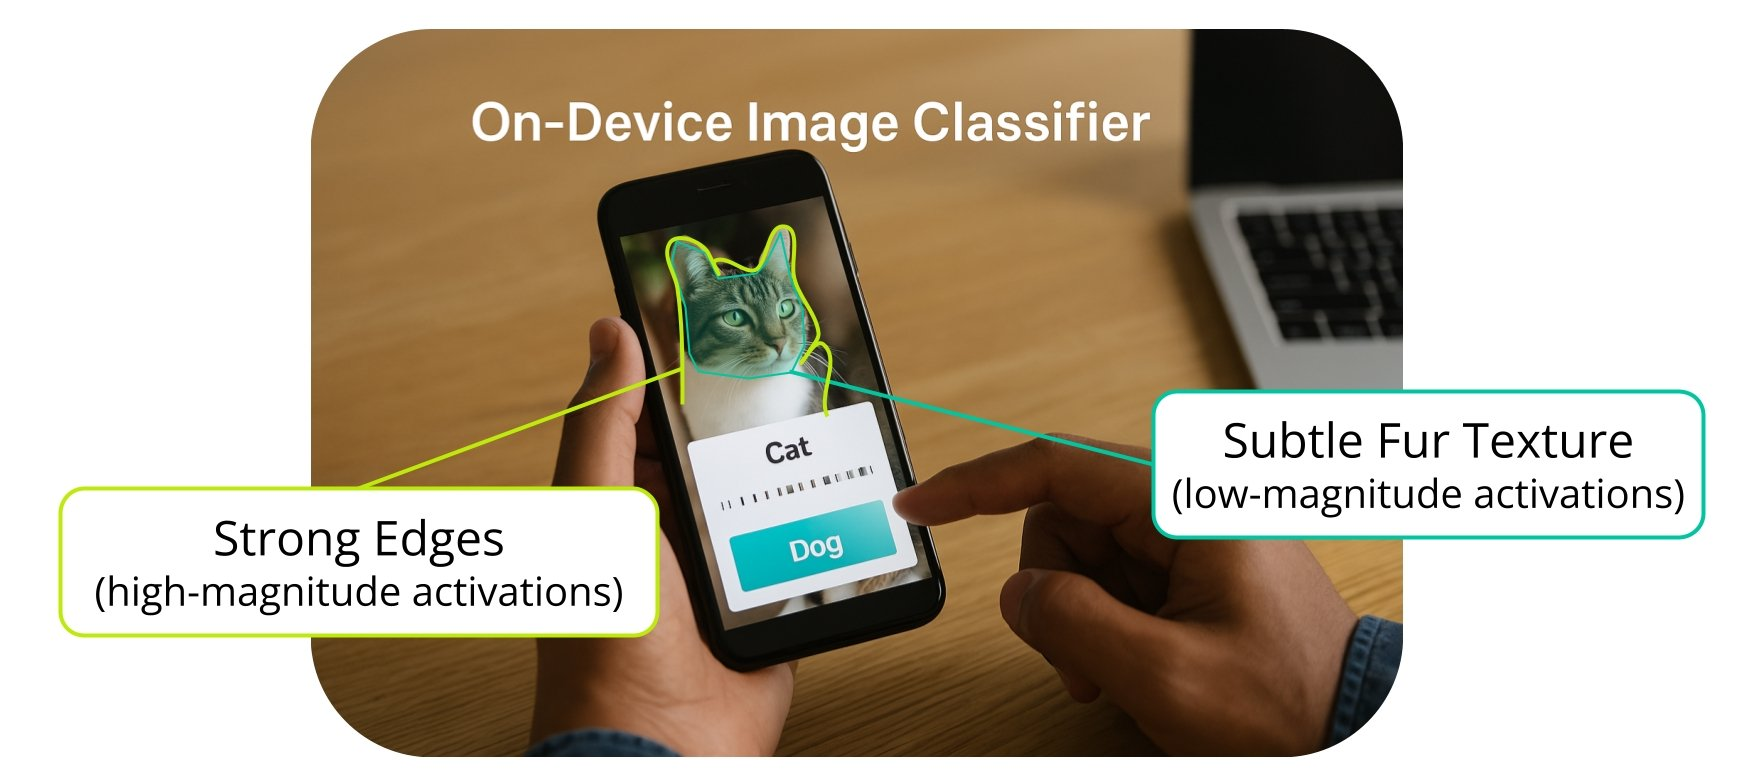

**Per-tensor quantization** computes a single scale factor and zero-point for an entire weight or activation tensor. Every value in that tensor uses the same mapping function. This is simple, uses minimal metadata, and adds virtually no computational overhead. However, it can introduce significant rounding errors if the values within the tensor have widely different ranges.

**Per-channel quantization** assigns a unique scale and zero-point to each channel within a tensor (e.g., each output feature map of a convolutional layer). This allows the mapping to adapt to the unique distribution of values in each channel, which drastically reduces quantization noise and preserves model accuracy, especially in deeper layers. The trade-off is a slight increase in memory and compute overhead.

Consider an on-device image classifier identifying cats and dogs. Some channels in a convolutional layer might specialize in detecting **strong edges** (producing high-magnitude activations), while others focus on **subtle fur texture** (low-magnitude activations).

With **per-tensor** quantization, the single scale factor is determined by the high-magnitude values from the "edge" channels. This coarse scale causes the small, nuanced values from the "fur" channels to be rounded into just a few integer levels, losing the detail needed for accurate classification.

With **per-channel** quantization, each feature map gets its own tailored scale. The edge-detector channel uses a coarse scale appropriate for its wide range, while the fur-texture channel uses a fine-grained scale to map its small variations across the full integer range. This preserves critical detail for a tiny metadata cost.

**Rule of thumb:** Start with a quick, weights-only, per-tensor quantization pass. If accuracy remains acceptable, you are done. If accuracy drops too much, apply per-channel quantization to layers where the value distribution varies significantly across channels.


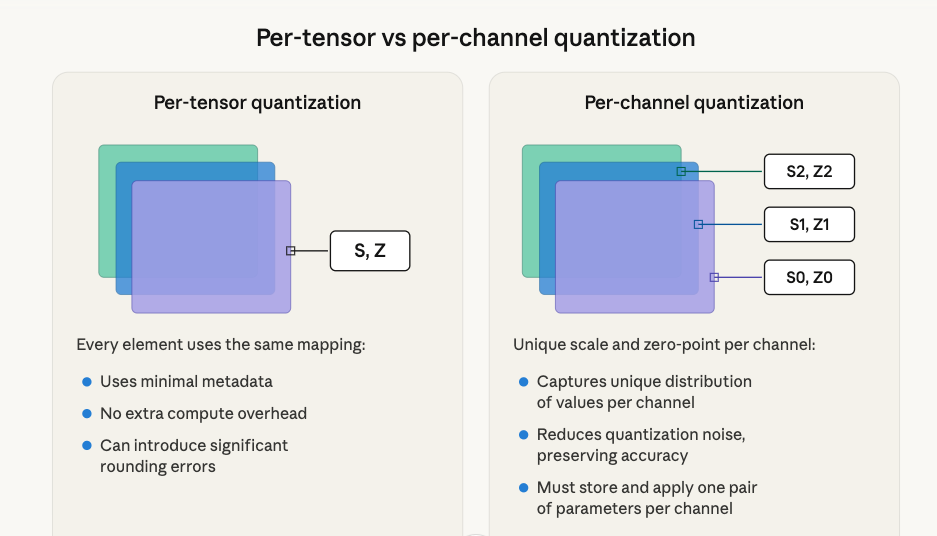

### Per-Channel Quantization


In [ ]:
def linear_q_symmetric_per_channel(tensor, dim=0, dtype=torch.int8):
    """Symmetric quantization with a separate scale per channel."""

    output_dim = tensor.shape[dim]
    scale = torch.zeros(output_dim)

    for i in range(output_dim):
        sub_tensor = tensor.select(dim, i)
        scale[i] = get_q_scale_symmetric(sub_tensor, dtype)

    # Reshape scale for broadcasting
    shape = [1] * tensor.dim()
    shape[dim] = -1
    scale = scale.view(shape)

    quantized_tensor = linear_q_with_scale_and_zero_point(
        tensor, scale, zero_point=0, dtype=dtype)

    return quantized_tensor, scale


In [ ]:
def quantization_error(original, dequantized):
    return (original - dequantized).square().mean()

# Compare per-tensor vs per-channel
qt_t, s_t = linear_q_symmetric(test_tensor)
dq_t = linear_dequantization(qt_t, s_t, 0)
mse_t = quantization_error(test_tensor, dq_t).item()

qt_c, s_c = linear_q_symmetric_per_channel(test_tensor, dim=0)
dq_c = linear_dequantization(qt_c, s_c, 0)
mse_c = quantization_error(test_tensor, dq_c).item()

print(f"Per-Tensor  MSE: {mse_t:.4f}")
print(f"Per-Channel MSE: {mse_c:.4f}")
print(f"\nPer-channel reduces error by {(1 - mse_c/mse_t)*100:.1f}%")


Per-Tensor  MSE: 2.5092
Per-Channel MSE: 1.8084

Per-channel reduces error by 27.9%


### Per-Group Quantization


In [ ]:
def linear_q_symmetric_per_group(tensor, group_size, dtype=torch.int8):
    """Symmetric quantization with a separate scale per group."""

    t_shape = tensor.shape
    assert t_shape[1] % group_size == 0
    assert tensor.dim() == 2

    tensor = tensor.view(-1, group_size)

    quantized_tensor, scale = linear_q_symmetric_per_channel(
        tensor, dim=0, dtype=dtype)

    quantized_tensor = quantized_tensor.view(t_shape)

    return quantized_tensor, scale


def linear_dequantization_per_group(quantized_tensor, scale, group_size):
    """Dequantize a per-group quantized tensor."""

    q_shape = quantized_tensor.shape
    quantized_tensor = quantized_tensor.view(-1, group_size)

    dequantized_tensor = linear_dequantization(quantized_tensor, scale, 0)

    dequantized_tensor = dequantized_tensor.view(q_shape)

    return dequantized_tensor


In [ ]:
# Test per-group quantization
test_tensor_6x6 = torch.randn((6, 6))
group_size = 3

qt_g, s_g = linear_q_symmetric_per_group(
    test_tensor_6x6, group_size=group_size)

dq_g = linear_dequantization_per_group(qt_g, s_g, group_size)
mse_g = quantization_error(test_tensor_6x6, dq_g).item()

# Compare with per-tensor
qt_t2, s_t2 = linear_q_symmetric(test_tensor_6x6)
dq_t2 = linear_dequantization(qt_t2, s_t2, 0)
mse_t2 = quantization_error(test_tensor_6x6, dq_t2).item()

print(f"Per-Tensor MSE:              {mse_t2:.6f}")
print(f"Per-Group  MSE (group={group_size}):  {mse_g:.6f}")
print(f"\nScales stored for per-tensor: 1")
print(f"Scales stored for per-group:  {s_g.numel()}")


Per-Tensor MSE:              0.000012
Per-Group  MSE (group=3):  0.000009

Scales stored for per-tensor: 1
Scales stored for per-group:  12


---
## Post-Training Quantization (PTQ)

PTQ involves quantizing a model's parameters **after** training.

### Dynamic Quantization

After data passes through a hidden layer, activations are collected and used to compute scale and zero-point on the fly:

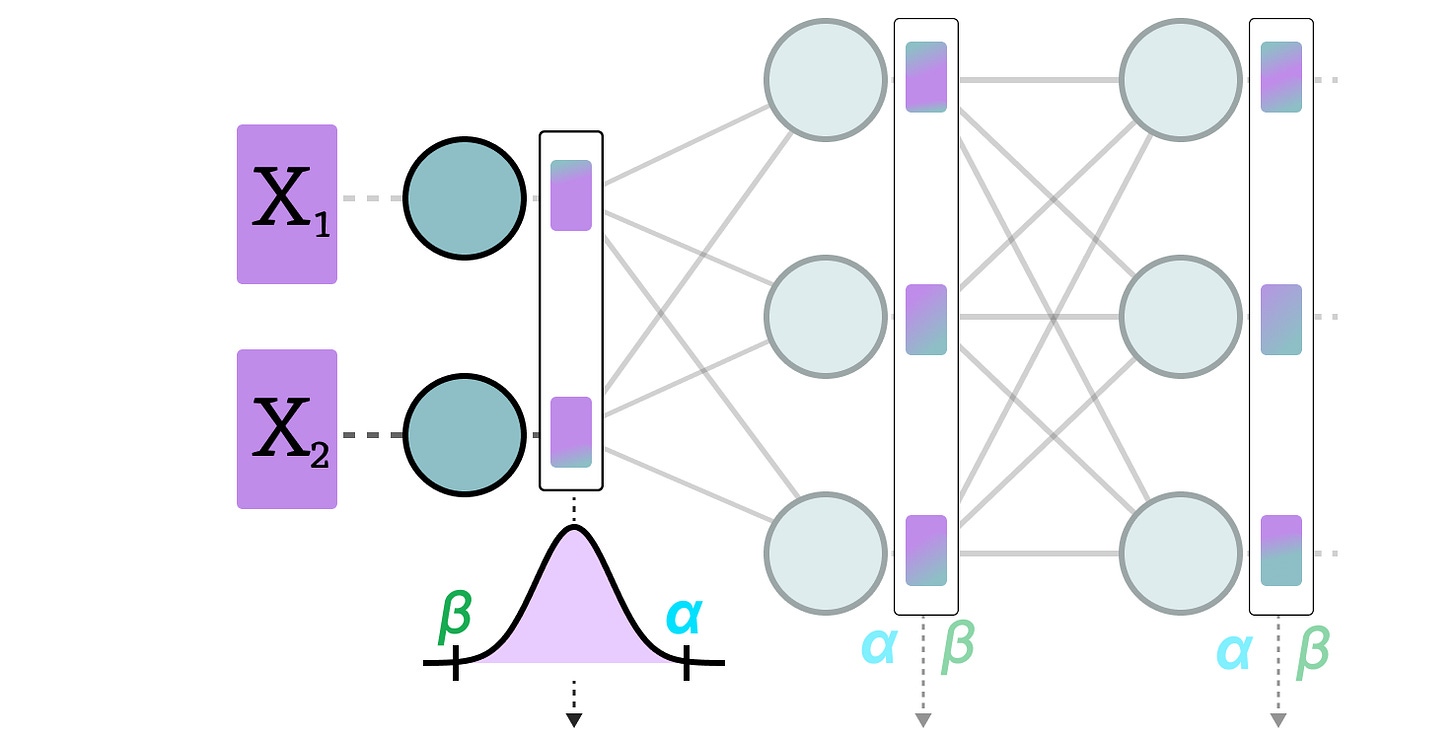

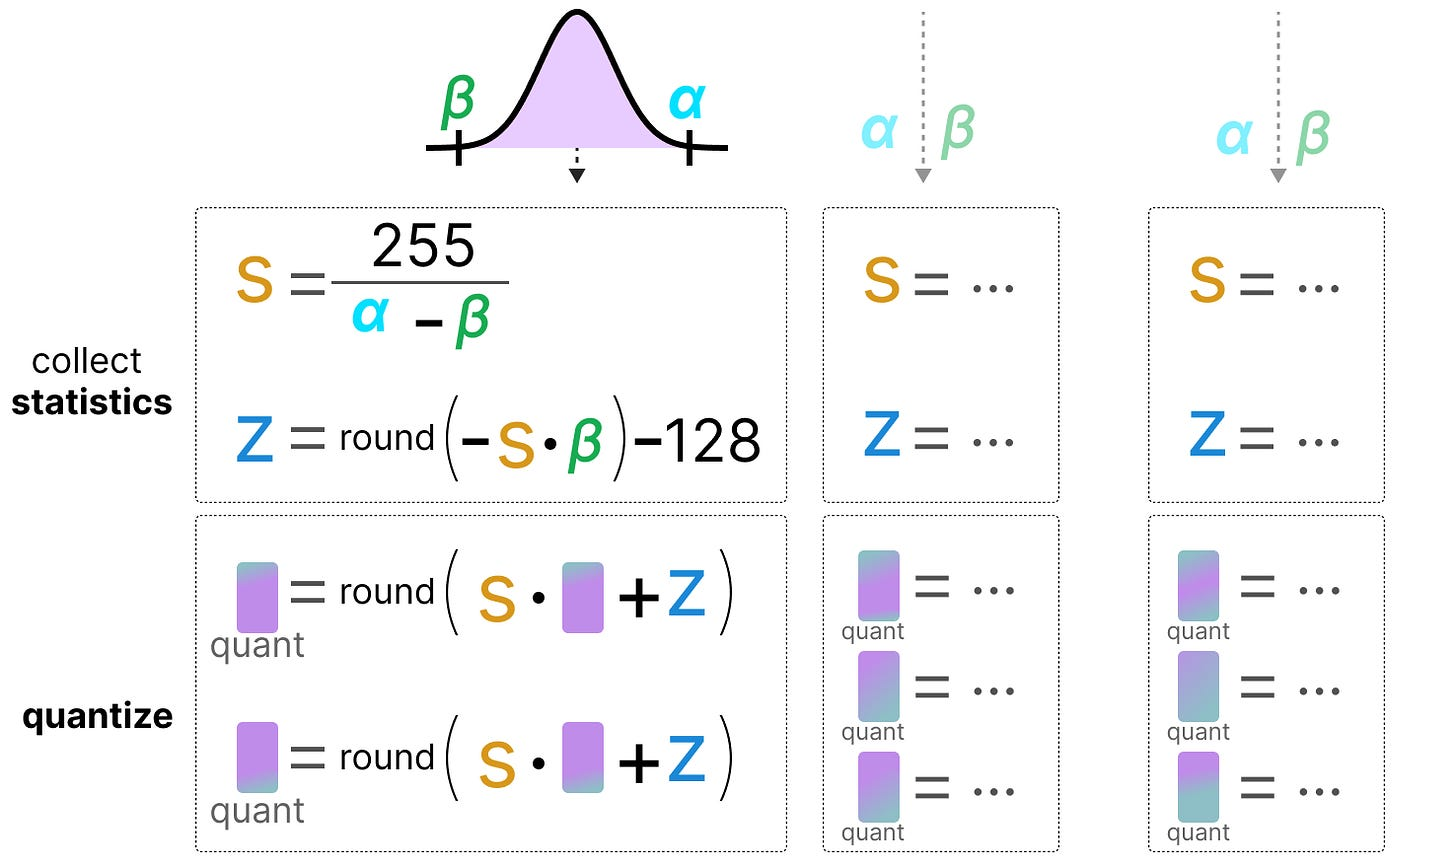

This process is repeated at each layer, so each layer has its own quantization parameters.

### Static Quantization

Static quantization uses a **calibration dataset** to pre-compute scale and zero-point before inference:

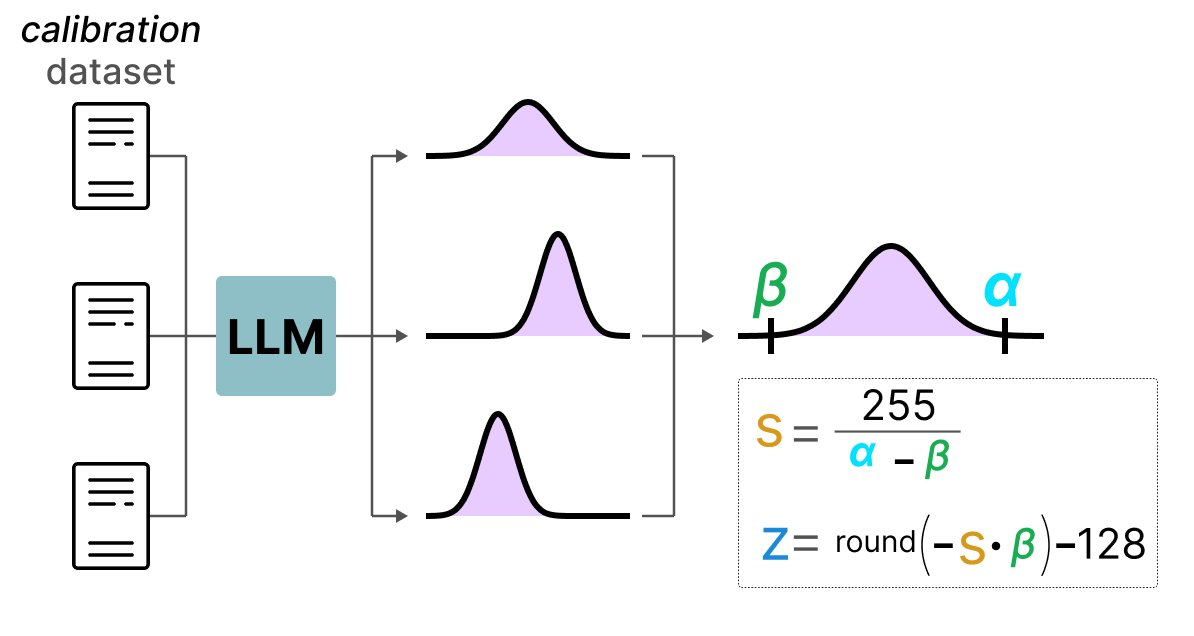

Dynamic quantization is more accurate but slower. Static quantization is less accurate but faster.


### Hands-On: PTQ with Optimum Quanto on TinyLlama

Let us apply what we have learned. We will quantize TinyLlama-1.1B to INT8 using Optimum Quanto, a lightweight post-training quantization library from HuggingFace.

We will compare the **original FP32 model** vs the **quantized INT8 model** on three things: model size, inference latency, and output quality.


In [ ]:
!pip install -q optimum-quanto transformers accelerate torch


In [ ]:
import torch
import time
from transformers import AutoModelForCausalLM, AutoTokenizer
from optimum.quanto import quantize, freeze, qint8

MODEL_ID = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
DEVICE   = "cuda" if torch.cuda.is_available() else "cpu"
SEED     = 42

print(f"Device: {DEVICE}")


Device: cuda


In [ ]:
def get_model_size_mb(model):
    """Get model size in MB by summing parameter memory."""
    total = sum(p.nelement() * p.element_size() for p in model.parameters())
    return total / (1024 * 1024)


def generate_text(model, tokenizer, prompt, max_new_tokens=50):
    """Generate text and return output + latency."""
    messages = [{"role": "user", "content": prompt}]
    text = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(text, return_tensors="pt").to(model.device)

    torch.manual_seed(SEED)
    start = time.time()
    with torch.no_grad():
        output = model.generate(**inputs, max_new_tokens=max_new_tokens,
                                do_sample=False)
    latency = time.time() - start

    generated = tokenizer.decode(output[0][inputs.input_ids.shape[1]:],
                                 skip_special_tokens=True)
    return generated, latency


#### Load the original (FP32) model


In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
model_fp32 = AutoModelForCausalLM.from_pretrained(
    MODEL_ID, torch_dtype=torch.float32, device_map=DEVICE)

fp32_size = get_model_size_mb(model_fp32)
print(f"FP32 model size: {fp32_size:.1f} MB")


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

FP32 model size: 4196.4 MB


In [ ]:
prompt = "Explain quantization in machine learning in 2 sentences."

fp32_output, fp32_latency = generate_text(model_fp32, tokenizer, prompt)

print(f"FP32 latency: {fp32_latency:.2f}s")
print(f"FP32 output:\n{fp32_output}")


FP32 latency: 1.50s
FP32 output:
Quantization is a technique used in machine learning to reduce the size of the input data without losing any information. It involves converting the input data into a smaller range of values, typically between 0 and 1, to reduce the computational complexity of the


#### Quantize to INT8 with Quanto

The quantization process has two steps:

1. **`quantize()`** — replaces weights with quantized placeholders (the model is now in a "fake quantized" state, weights are still computed on-the-fly from FP32)
2. **`freeze()`** — this is the **calibration and freeze step**. It finalizes the quantized weights by computing the optimal scale factors and permanently converting weights to INT8. After freeze, the model uses true INT8 weights.


In [ ]:
# Step 1: Quantize — replace linear layer weights with INT8 placeholders
quantize(model_fp32, weights=qint8)
print("Quantization placeholders applied.")

# Step 2: Freeze — calibrate and lock in the INT8 weights
# This computes the final scale factors and converts weights permanently
freeze(model_fp32)
print("Model frozen — weights are now true INT8.")

int8_size = get_model_size_mb(model_fp32)
print(f"\nINT8 model size: {int8_size:.1f} MB")
print(f"Compression:     {fp32_size / int8_size:.1f}x smaller")


Quantization placeholders applied.
Model frozen — weights are now true INT8.

INT8 model size: 4196.4 MB
Compression:     1.0x smaller


In [ ]:
int8_output, int8_latency = generate_text(model_fp32, tokenizer, prompt)

print(f"INT8 latency: {int8_latency:.2f}s")
print(f"INT8 output:\n{int8_output}")


INT8 latency: 2.65s
INT8 output:
Quantization is a technique used in machine learning to reduce the size of the input data without losing any information. It involves converting the input data into a smaller range of values, typically between 0 and 1, to reduce the computational complexity of the


#### Comparison


In [ ]:
print("=" * 60)
print(f"{'Metric':<25} {'FP32':>15} {'INT8':>15}")
print("=" * 60)
print(f"{'Model size (MB)':<25} {fp32_size:>15.1f} {int8_size:>15.1f}")
print(f"{'Latency (s)':<25} {fp32_latency:>15.2f} {int8_latency:>15.2f}")
print(f"{'Speedup':<25} {'1.0x':>15} {f'{fp32_latency/int8_latency:.2f}x':>15}")
print("=" * 60)

print(f"\n--- FP32 output ---\n{fp32_output}")
print(f"\n--- INT8 output ---\n{int8_output}")


Metric                               FP32            INT8
Model size (MB)                    4196.4          4196.4
Latency (s)                          1.50            2.65
Speedup                              1.0x           0.57x

--- FP32 output ---
Quantization is a technique used in machine learning to reduce the size of the input data without losing any information. It involves converting the input data into a smaller range of values, typically between 0 and 1, to reduce the computational complexity of the

--- INT8 output ---
Quantization is a technique used in machine learning to reduce the size of the input data without losing any information. It involves converting the input data into a smaller range of values, typically between 0 and 1, to reduce the computational complexity of the


**What to look for:**

- **Size** should drop by roughly 4x (FP32 → INT8 = 32 bits → 8 bits)
- **Latency** may improve modestly on GPU (bigger gains on CPU)
- **Output quality** should be nearly identical for weight-only INT8 — this is the sweet spot of quantization, where you lose almost nothing but save significant memory


### The Realm of 4-bit Quantization

### GPTQ

GPTQ uses asymmetric quantization and processes each layer independently:

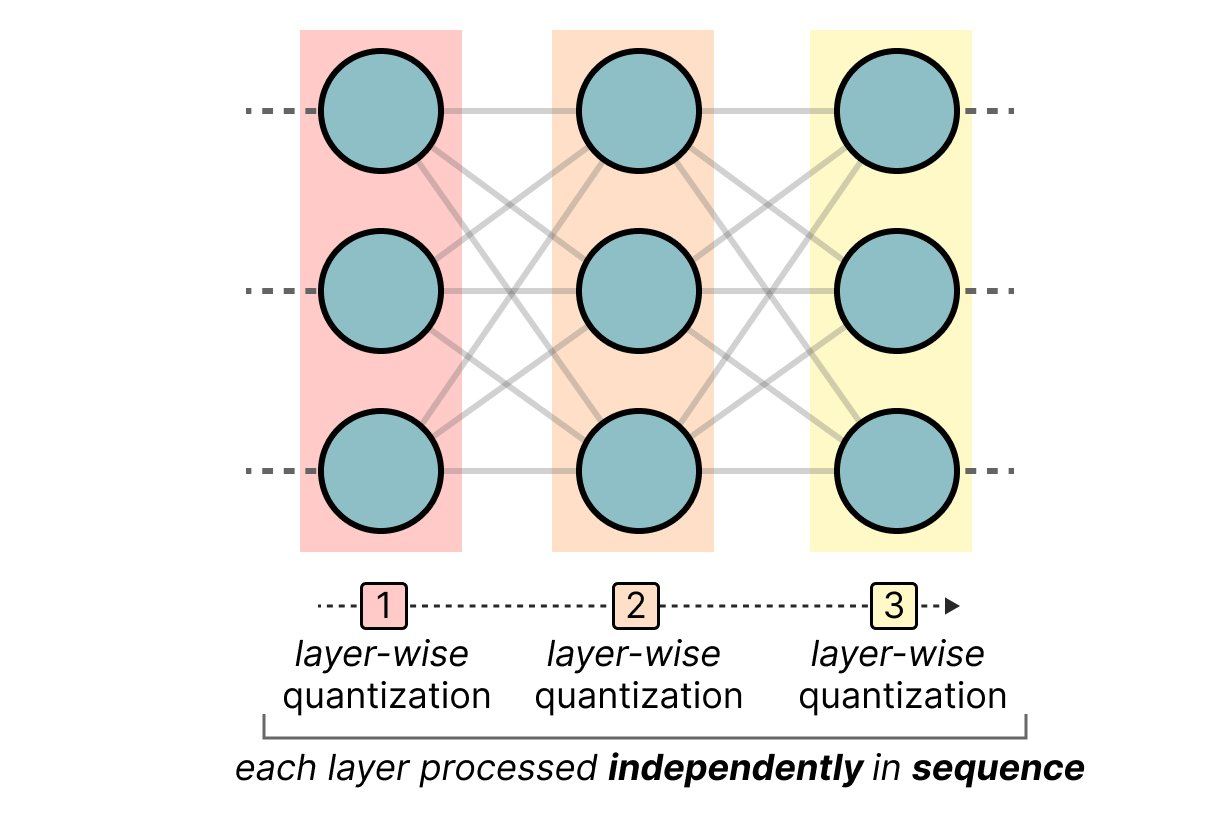

It computes the **inverse Hessian** — telling us how sensitive the output is to each weight:

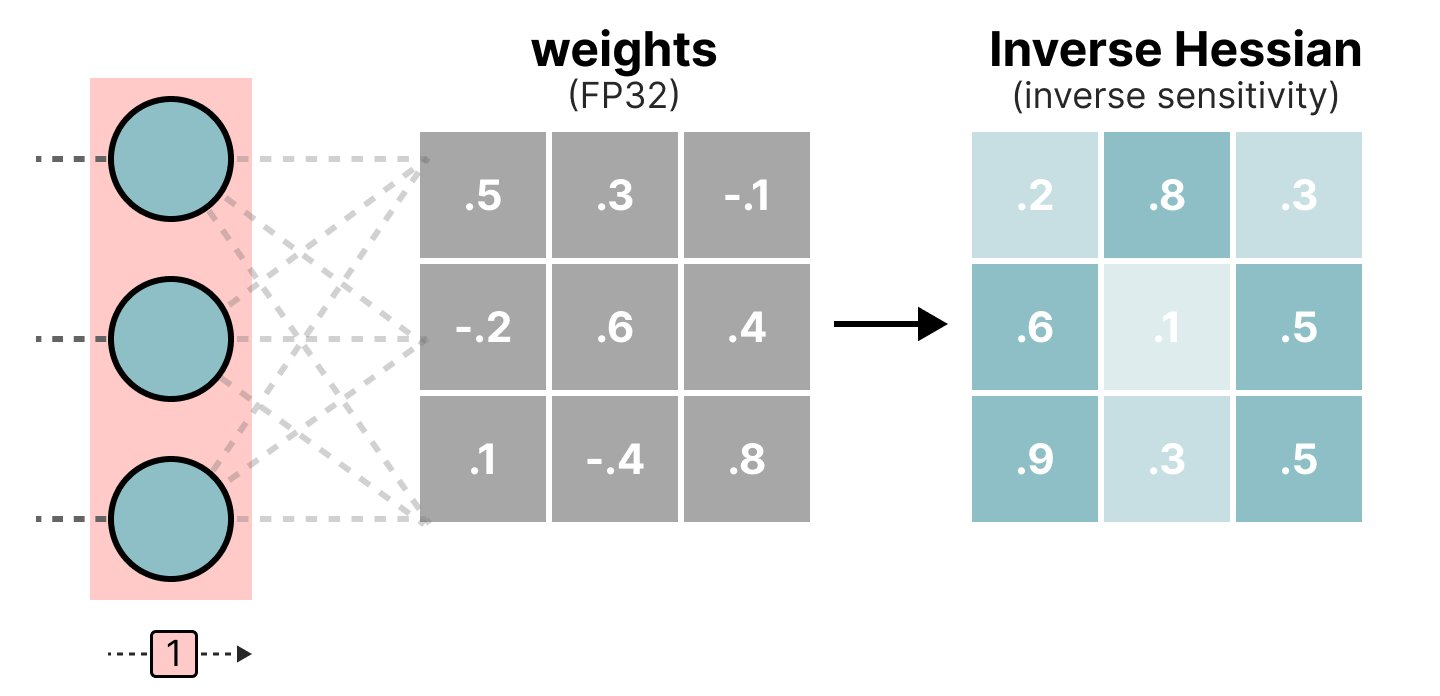

The process: quantize one weight, compute the weighted error, redistribute to remaining weights:

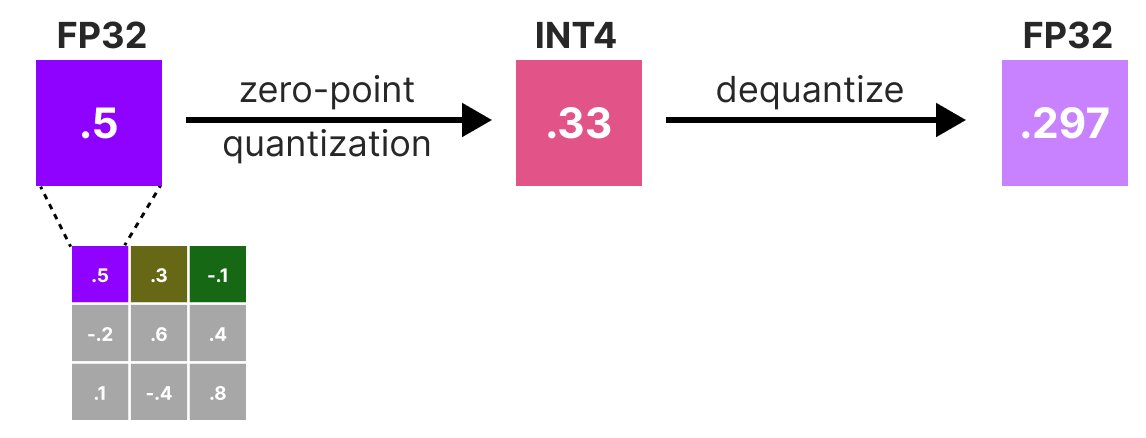

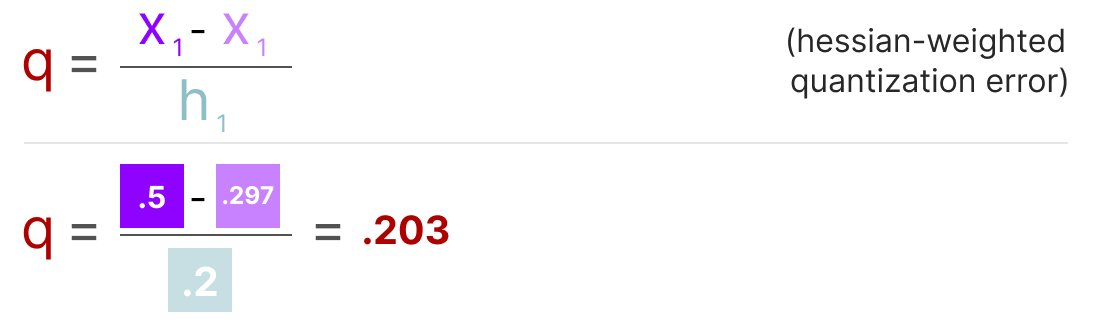

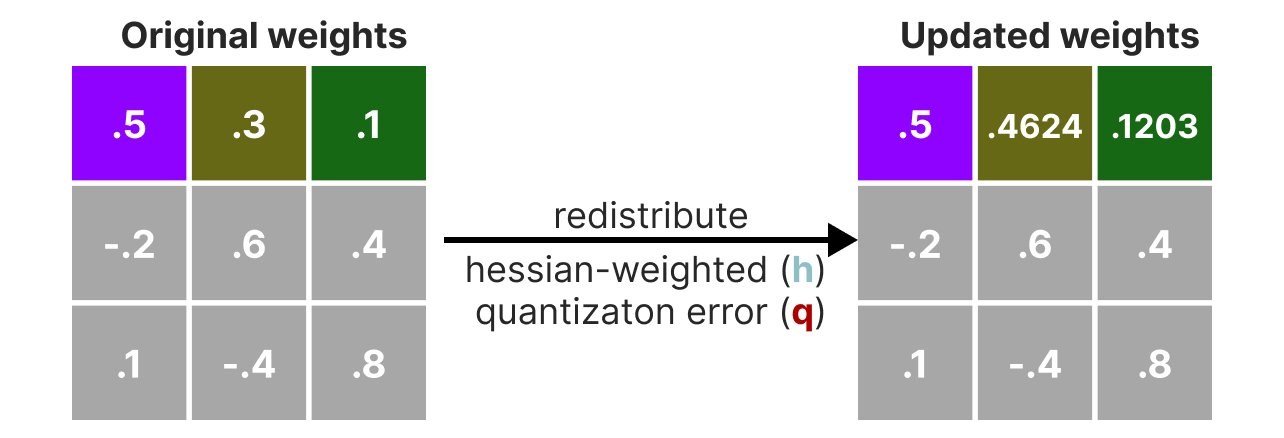


### GGUF

GGUF allows offloading layers to the CPU. It uses a two-level block hierarchy: **super blocks** containing **sub blocks**.

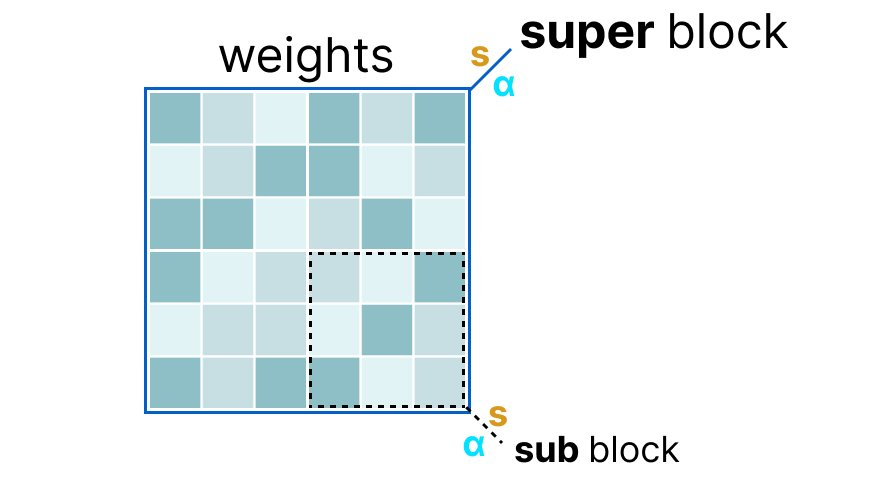

Each sub block is quantized using absmax:

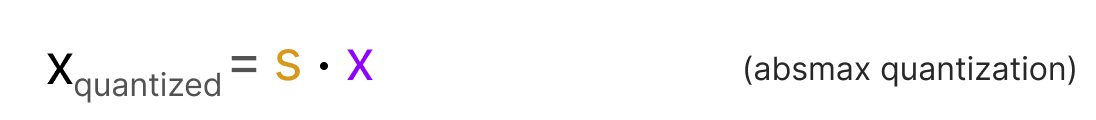

The sub block's scale factor is itself quantized using the super block's scale factor:

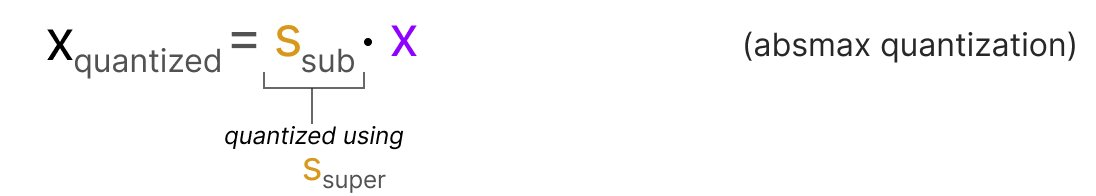

Different quantization levels (2-bit, 4-bit, 6-bit):

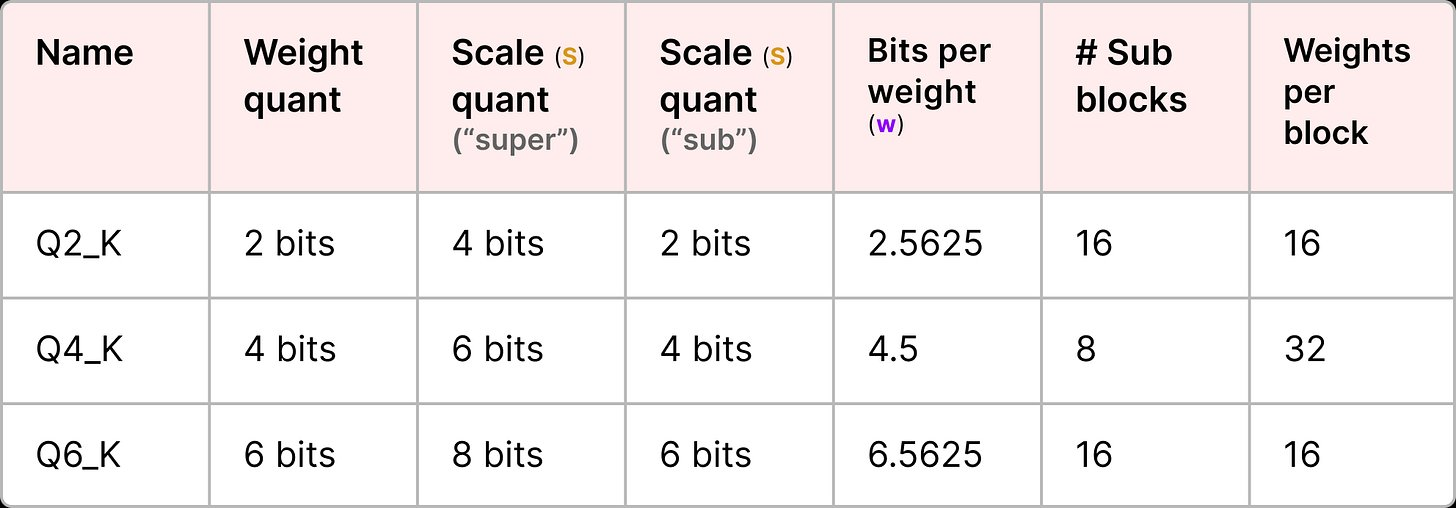


---
## Quantization-Aware Training (QAT)

Quantization-Aware Training (QAT) differs fundamentally from Post-Training Quantization (PTQ). Instead of converting a fully trained model and accepting the performance drop, QAT integrates quantization into a brief fine-tuning phase, teaching the model to compensate for precision loss.

### How QAT works

The core mechanism involves simulating quantization noise during the forward pass of training through two key techniques:

**Fake-Quant modules:** Key layers are wrapped with operators that mimic low-bit inference. During training, these modules take full-precision weights and activations, quantize them to the target bit-width (e.g., INT8), and then immediately dequantize them back to floating-point. This injects realistic rounding errors, forcing the network to "feel" the effects of quantization.

**Straight-Through Estimator (STE):** Since rounding is non-differentiable, standard backpropagation would fail. The STE allows gradients to flow through the fake-quant module as if it were an identity function, enabling the underlying floating-point parameters to be updated.

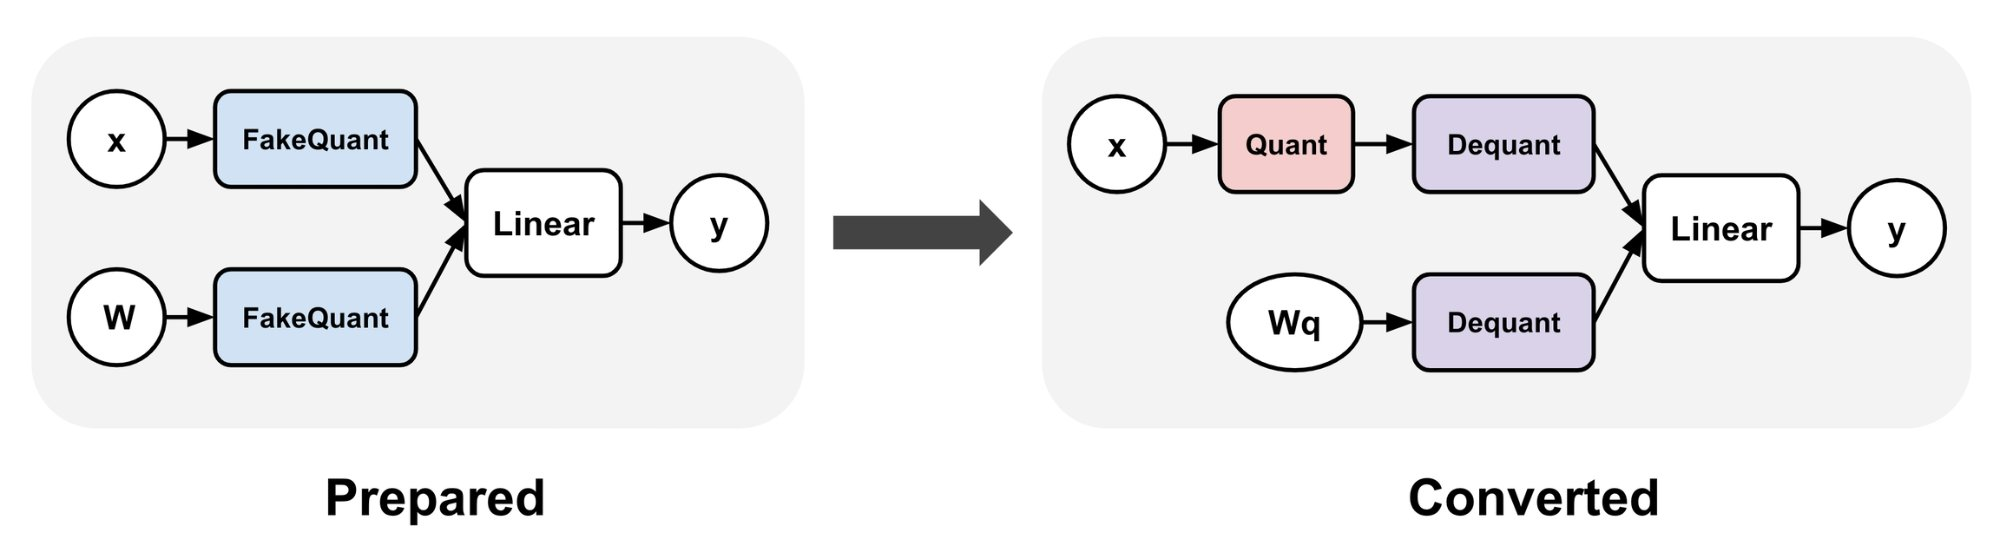

*Left (Prepared):* During QAT training, both inputs (x) and weights (W) pass through FakeQuant modules before the Linear layer. *Right (Converted):* After training, the model is converted — inputs go through real Quant → Dequant, weights are stored pre-quantized (Wq) and dequantized before the Linear layer.


### When to choose QAT over PTQ

**Significant accuracy drop:** When a simple PTQ pass causes accuracy to fall by more than 2–3%.

**Challenging data dynamics:** If input data contains extreme outliers or is expected to shift over time.

**High-fidelity requirements:** For safety-critical applications (medical imaging, autonomous systems, financial forecasting) where even small errors are unacceptable.

QAT can recover 95–99% of the original FP32 accuracy. Gains typically plateau after 1–5 epochs.


### The loss landscape perspective

QAT explores the loss landscape for **wide minima** to minimize quantization error. Narrow minima produce larger errors when weights are rounded.

Without QAT, gradient descent may settle in a narrow minimum — lower FP32 loss but higher quantization error. With QAT, a different weight in a wide minimum is selected — slightly higher FP32 loss but much lower quantization error. PTQ achieves lower loss in FP32, but QAT achieves lower loss in the actual quantized precision (e.g., INT4).


---

### Hands-On: QAT with Unsloth + TorchAO

Unsloth collaborates with the PyTorch TorchAO team to provide QAT directly during fine-tuning. QAT can recover up to **70% of the lost accuracy** from naive 4-bit quantization, achieving **1–3% improvement** on benchmarks like GPQA and MMLU Pro — with no extra overhead during inference.


In [ ]:
!pip install --upgrade --no-cache-dir unsloth unsloth_zoo -q
!pip install torchao==0.14.0 -q


**Load the model in 16-bit and enable QAT via `qat_scheme`**

Unlike standard LoRA fine-tuning, we set `qat_scheme` when creating the PEFT model. This inserts fake-quantize operations into the linear layers. Supported schemes: `int4`, `int8-int4`, `fp8-int4`, `fp8-fp8`.


In [ ]:
from unsloth import FastLanguageModel

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="Qwen/Qwen3-4B",
    max_seq_length=2048,
    load_in_4bit=False,
    load_in_16bit=True,
)

model = FastLanguageModel.get_peft_model(
     model,
     r=16,
     target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj"],
     lora_alpha=32,
     qat_scheme="int4",     # Enable QAT — inserts fake-quant ops
)


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
Unsloth: Your Flash Attention 2 installation seems to be broken. Using Xformers instead. No performance changes will be seen.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.4.2: Fast Qwen3 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA A100-SXM4-80GB. Num GPUs = 1. Max memory: 79.251 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/237 [00:00<?, ?B/s]

...

added_tokens.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

unsloth/Qwen3-4B does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.
Unsloth: Applying QAT to mitigate quantization degradation


Unsloth 2026.4.2 patched 36 layers with 36 QKV layers, 36 O layers and 36 MLP layers.


**Fine-tune with QAT enabled**

Training proceeds normally with SFTTrainer. The fake-quant modules inside the model simulate INT4 rounding during every forward pass, so the model learns to compensate.


In [ ]:
from datasets import load_dataset

dataset = load_dataset("tatsu-lab/alpaca", split="train[:200]")

def format_example(example):
    if example["input"]:
        text = f"### Instruction:\n{example['instruction']}\n\n### Input:\n{example['input']}\n\n### Response:\n{example['output']}"
    else:
        text = f"### Instruction:\n{example['instruction']}\n\n### Response:\n{example['output']}"
    return {"text": text}

dataset = dataset.map(format_example)
print(f"Training examples: {len(dataset)}")

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001-a09b74b3ef9c3b(…):   0%|          | 0.00/24.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/52002 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Training examples: 200


In [ ]:
from trl import SFTTrainer
from transformers import TrainingArguments
from unsloth import unsloth_train
#
trainer = SFTTrainer(
     model=model,
     tokenizer=tokenizer,
     train_dataset=dataset,
     dataset_text_field="text",
     max_seq_length=2048,
     args=TrainingArguments(
         per_device_train_batch_size=2,
         gradient_accumulation_steps=4,
         warmup_steps=5,
         max_steps=30,
         learning_rate=2e-4,
         bf16=True,
         logging_steps=5,
         output_dir="qat_output",
     ),
)

trainer_stats = unsloth_train(trainer)


Unsloth: Tokenizing ["text"] (num_proc=16):   0%|          | 0/200 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 200 | Num Epochs = 2 | Total steps = 30
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 33,030,144 of 4,055,498,240 (0.81% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Step,Training Loss
5,2.147103
10,1.695205
15,1.418060
20,1.429119
25,1.328237
30,1.299645


**Convert fake-quant to real quantization and export**

After training, TorchAO converts the fake-quant operations into actual quantize/dequantize operations. Then we export using `save_pretrained_torchao`.


In [ ]:
!pip install torchao -q

In [ ]:
# Step 1: Convert fake-quant ops to real quantization
#from torchao.quantization import quantize_
#from torchao.quantization.qat import QATConfig
#quantize_(model, QATConfig(step="convert"))

# Step 2: Export — no torchao_config needed, it's already on the model
#model.save_pretrained_torchao("qat_model_output")

**What QAT gives you:**

| Aspect | Naive PTQ (4-bit) | QAT (4-bit) |
|--------|-------------------|-------------|
| Method | Quantize after training | Fine-tune with fake-quant, then convert |
| Accuracy recovery | — | Recovers 45–70% of lost accuracy |
| Benchmark improvement | Baseline | +1–3% on GPQA, MMLU Pro |
| Inference overhead | None | None (identical at runtime) |
| Disk / memory usage | Same | Same |
| Training cost | None | 1–5 epochs of fine-tuning |
| Requires TorchAO | No | Yes (`qat_scheme` + `quantize_` + `QATConfig`) |

QAT has **no extra overhead during inference** — it uses the same disk and memory as naive quantization. The only cost is the fine-tuning step.


### The Era of 1-bit LLMs: BitNet

BitNet represents model weights using a single bit: either **-1** or **1**. It replaces standard linear layers with **BitLinear** layers:

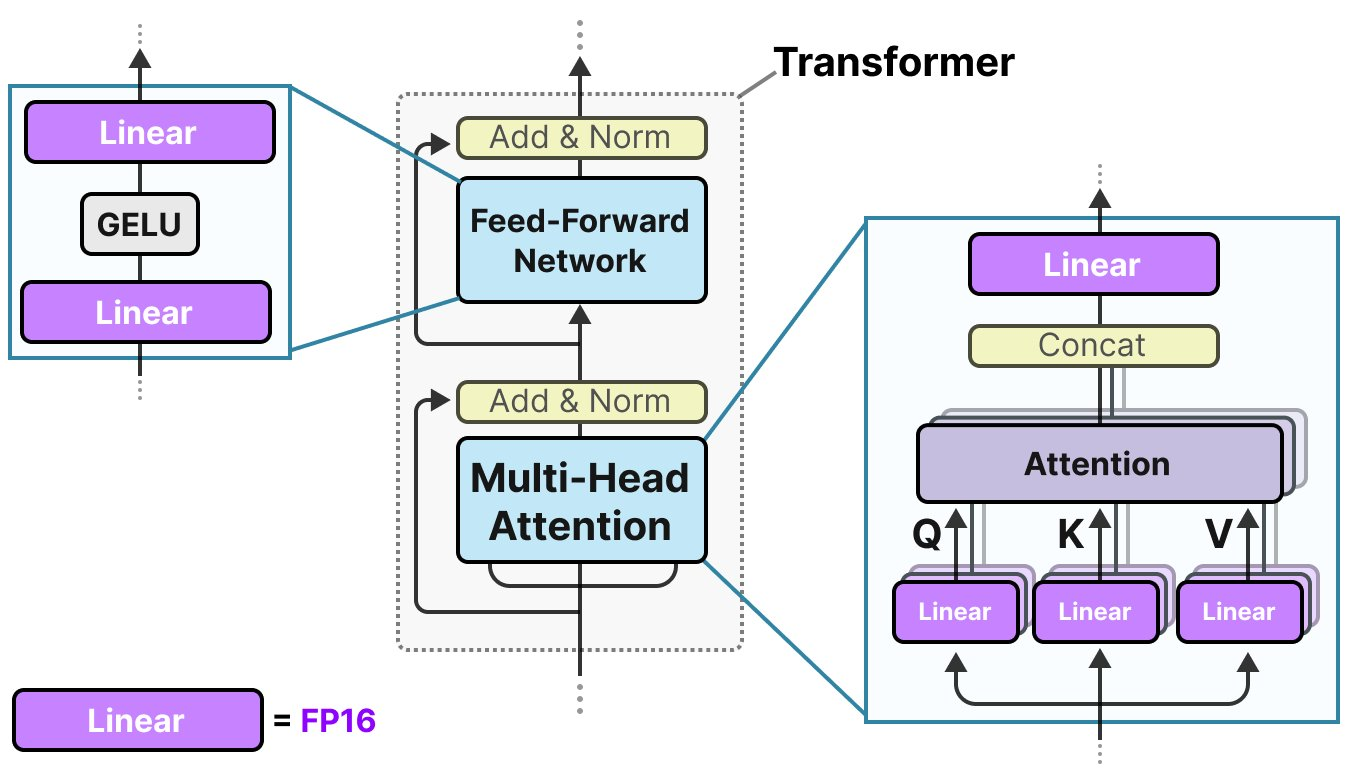

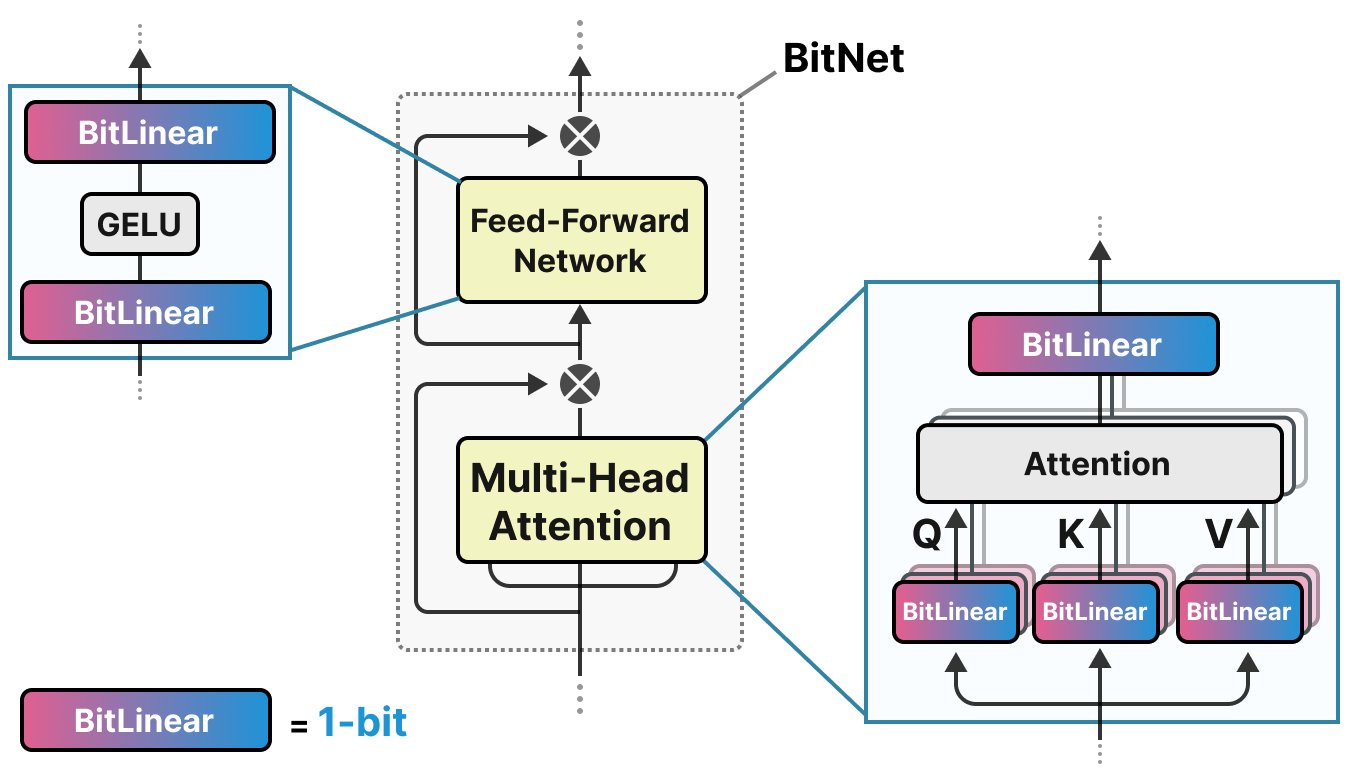

A BitLinear layer represents weights using 1-bit and activations using INT8:

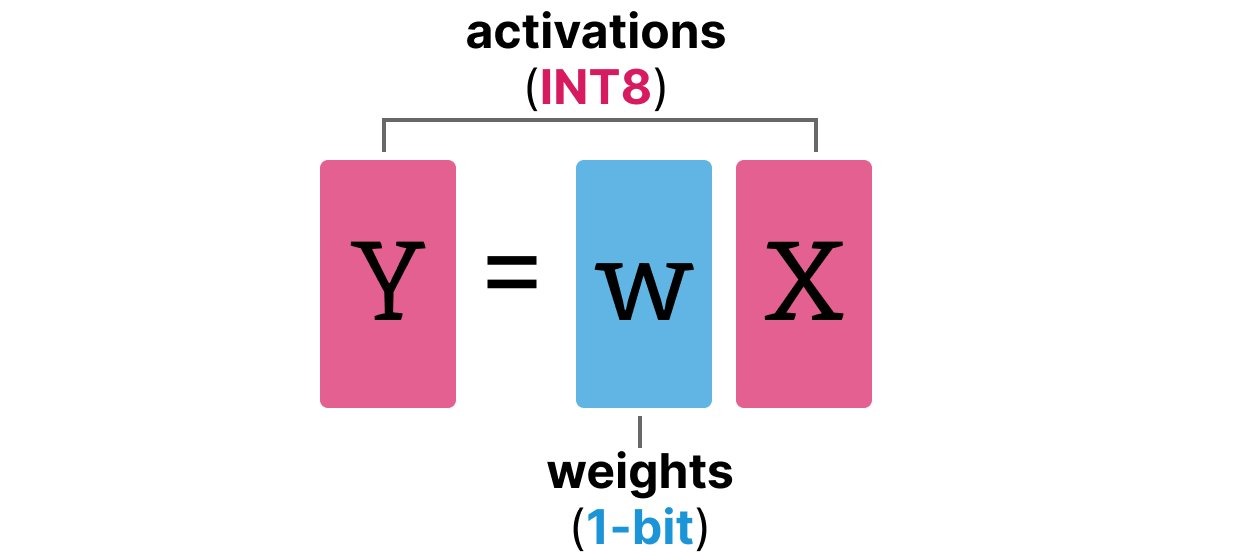

Like QAT, BitLinear performs "fake" quantization during training:

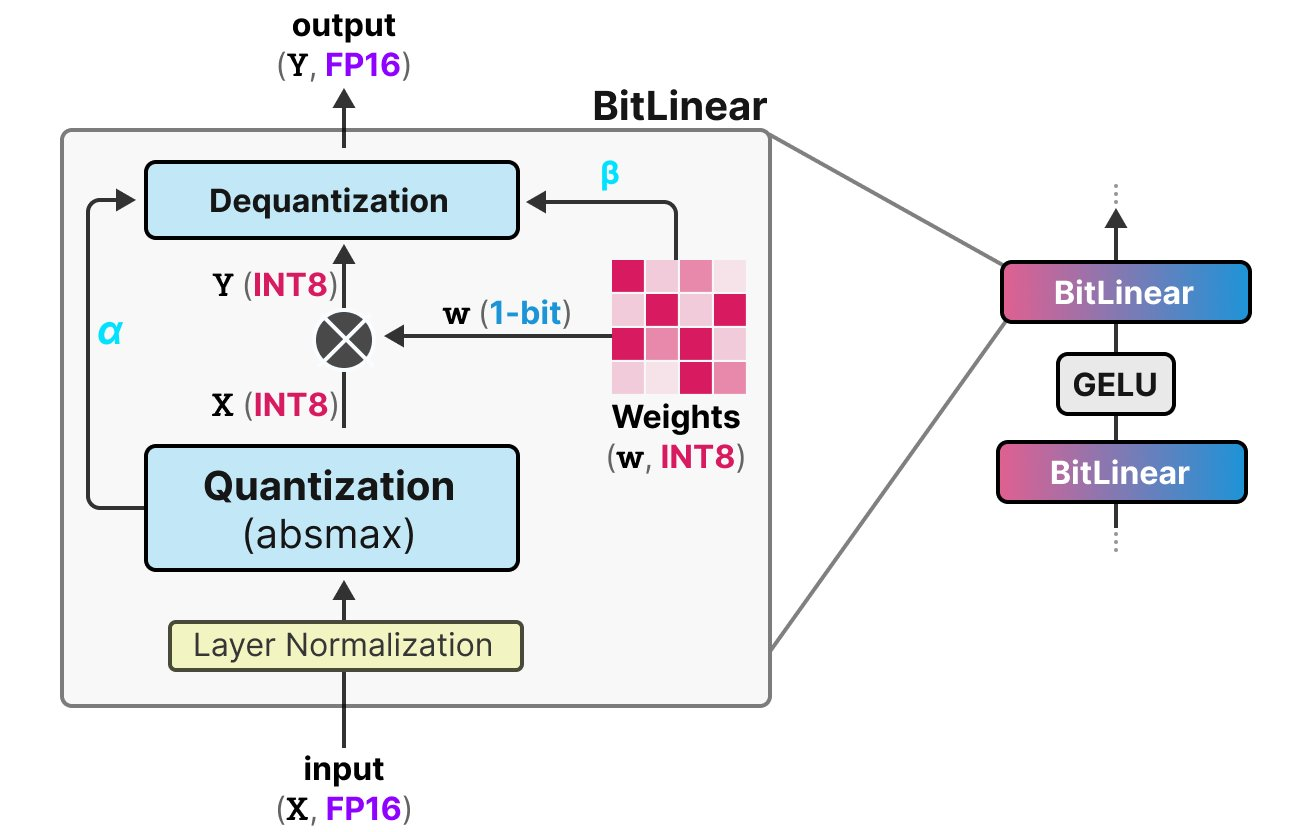


#### Weight Quantization

Weights are quantized to 1-bit using the **signum function**:

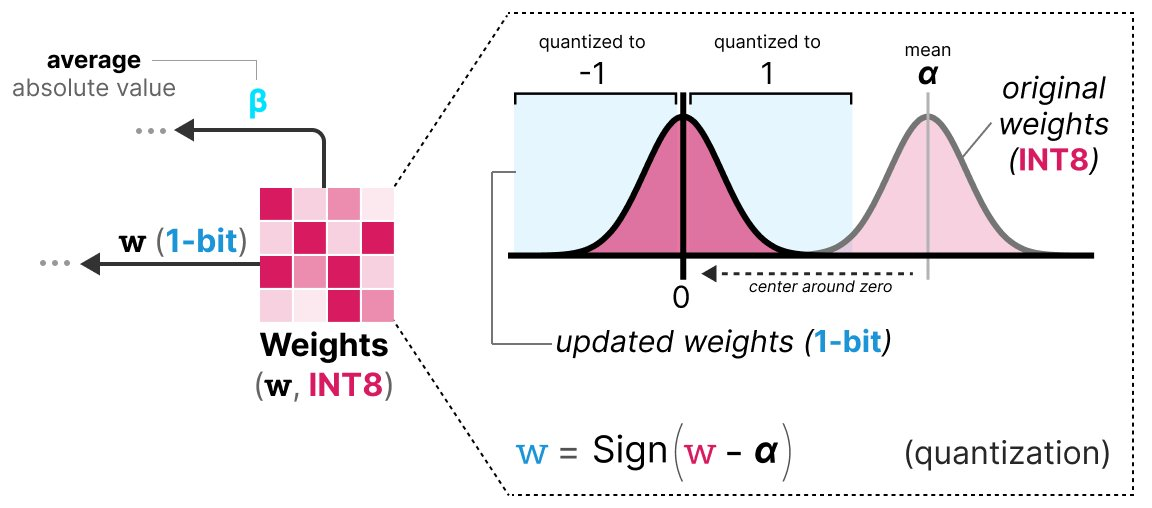

#### Activation Quantization

BitLinear uses **absmax quantization** to convert activations from FP16 to INT8:

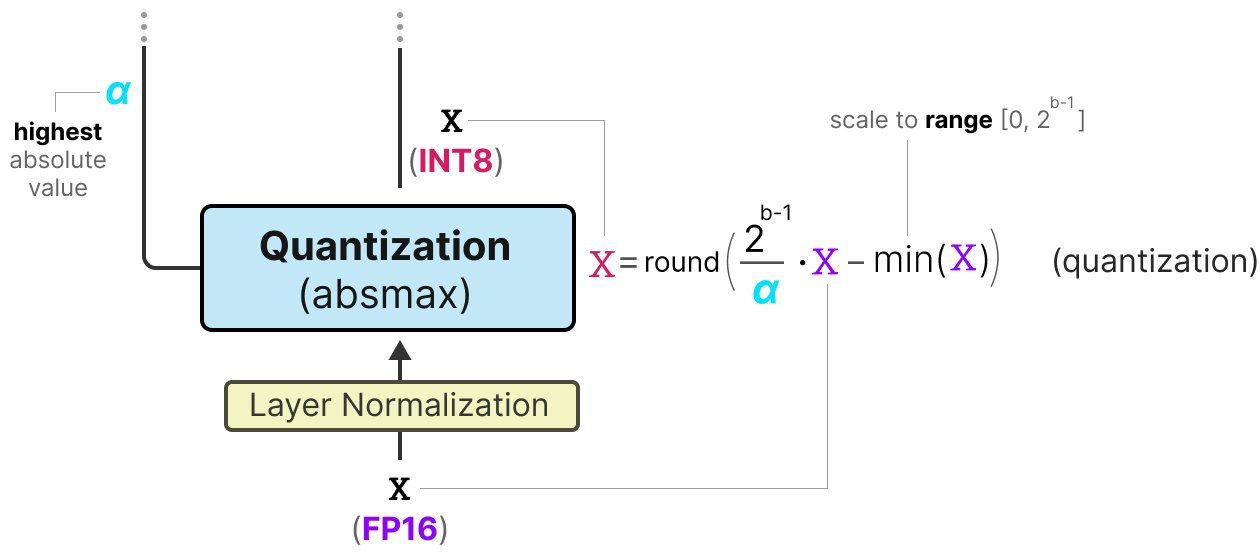

#### Dequantization

The output activations are rescaled with {α, β} back to FP16:

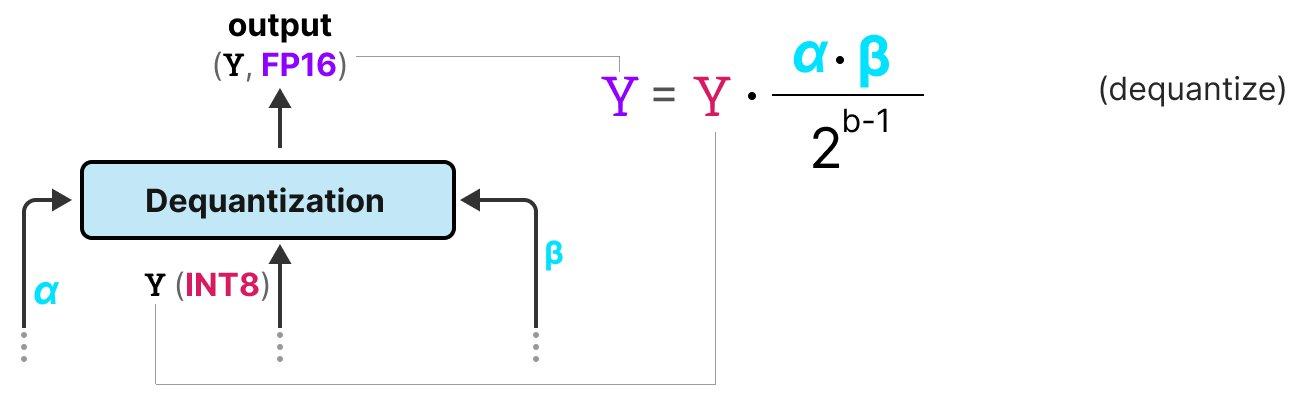


### All Large Language Models are in 1.58 Bits

BitNet 1.58b allows each weight to take one of three values: **{-1, 0, 1}** (ternary).

#### The Power of 0

In standard matrix multiplication, we both multiply and add:

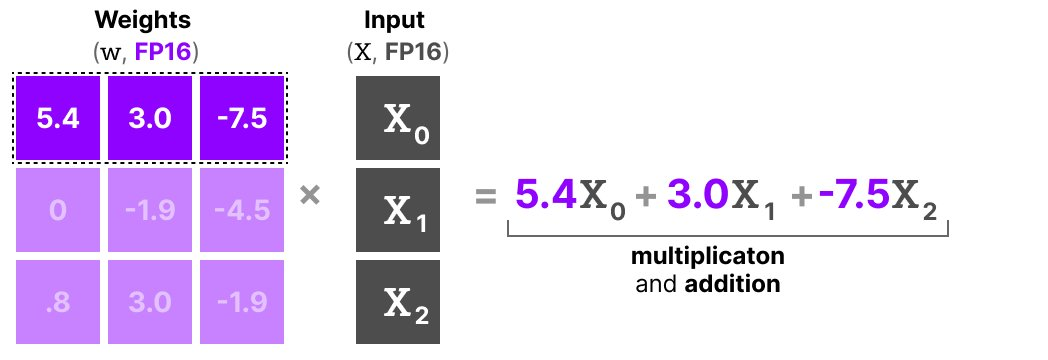

With ternary weights, only addition is needed:

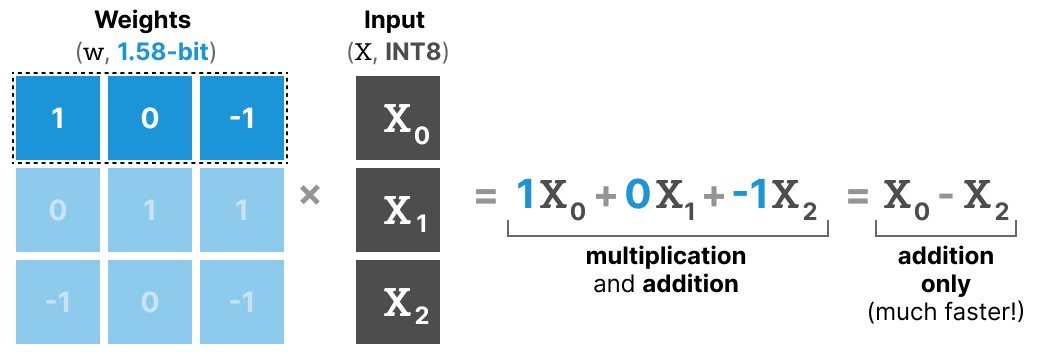

#### Quantization

BitNet 1.58b uses **absmean** quantization. Values are rounded to -1, 0, or 1:

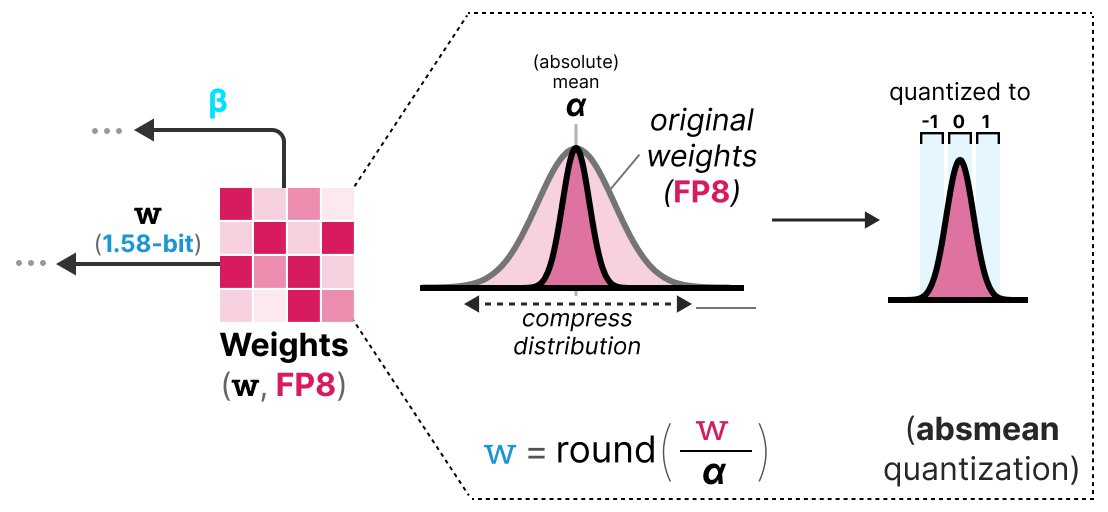

A **13B** BitNet 1.58b model is reported to be more efficient than a **3B** FP16 LLM.


---
## Loading Pre-Quantized Models

In practice, pre-quantized models are available on HuggingFace. Below are code snippets for each format.


### GPTQ


In [ ]:
# pip install optimum auto-gptq
# from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline
#
# model_id = "TheBloke/zephyr-7B-beta-GPTQ"
# tokenizer = AutoTokenizer.from_pretrained(model_id, use_fast=True)
# model = AutoModelForCausalLM.from_pretrained(
#     model_id, device_map="auto", trust_remote_code=False, revision="main")
# pipe = pipeline(model=model, tokenizer=tokenizer, task='text-generation')


### GGUF


In [ ]:
# pip install llama-cpp-python
# from llama_cpp import Llama
#
# llm = Llama.from_pretrained(
#     repo_id="TheBloke/zephyr-7B-beta-GGUF",
#     filename="zephyr-7b-beta.Q4_K_M.gguf",
#     n_gpu_layers=-1)


### AWQ


In [ ]:
# pip install vllm
# from vllm import LLM, SamplingParams
#
# sampling_params = SamplingParams(temperature=0.0, top_p=1.0, max_tokens=256)
# llm = LLM(model="TheBloke/zephyr-7B-beta-AWQ", quantization='awq',
#            dtype='half', gpu_memory_utilization=0.95, max_model_len=4096)


### BitsAndBytes (on-the-fly NF4)


In [ ]:
# pip install bitsandbytes
# from transformers import BitsAndBytesConfig, AutoModelForCausalLM
# from torch import bfloat16
#
# bnb_config = BitsAndBytesConfig(
#     load_in_4bit=True,
#     bnb_4bit_quant_type='nf4',
#     bnb_4bit_use_double_quant=True,
#     bnb_4bit_compute_dtype=bfloat16)
#
# model = AutoModelForCausalLM.from_pretrained(
#     "HuggingFaceH4/zephyr-7b-beta",
#     quantization_config=bnb_config, device_map='auto')


---
## Summary

| Concept | Key Point |
|---|---|
| **Quantization** | Reduce bit-width of model parameters to save memory and speed up inference |
| **Symmetric (absmax)** | Zero maps to zero. Scale = max(abs(x)) / q_max |
| **Asymmetric (zero-point)** | Shifts zero point. Better for skewed distributions |
| **Per-tensor** | One scale for the whole tensor. Fast but less precise |
| **Per-channel** | One scale per row/column. Good accuracy/overhead balance |
| **Per-group** | One scale per group. Most precise, most storage overhead |
| **PTQ (Dynamic)** | Compute scale/zp at runtime per layer |
| **PTQ (Static)** | Pre-compute scale/zp with calibration dataset |
| **QAT** | Simulate quantization during training. Finds wide minima |
| **GPTQ** | Layer-wise PTQ with inverse Hessian error redistribution. GPU-focused |
| **GGUF** | Block-wise quantization. CPU+GPU hybrid |
| **BitNet** | 1-bit weights (-1, 1). Signum function quantization |
| **BitNet 1.58b** | Ternary weights (-1, 0, 1). Replaces multiplication with addition |
